# Прогнозирование инвестиционного рейтинга компаний

### Введение

В данной работе рассматривается задача прогнозирования инвестиционного рейтинга компаний с использованием методов машинного обучения. Инвестиционный рейтинг отражает финансовую устойчивость компании и может использоваться как один из ориентиров при оценке кредитного риска, надежности эмитента и привлекательности компании для инвесторов.

Основная сложность проекта связана с ограниченностью исходных данных: доступный датасет содержит около 2000 наблюдений, что недостаточно для построения сложной универсальной модели, но позволяет реализовать базовый пайплайн машинного обучения и проверить, насколько финансовые показатели компаний связаны с уровнем их рейтинга. Поэтому работа строится в два этапа.

На первом этапе решается задача многоклассовой классификации. В рамках этого этапа проводится первичный анализ данных, предобработка признаков, обучение нескольких моделей машинного обучения и сравнение их качества с помощью метрик классификации.

На втором этапе проводится анализ важности признаков. После обучения модели необходимо определить, какие финансовые показатели оказывают наибольшее влияние на прогноз рейтинга. Это позволит не только интерпретировать результат модели, но и выделить ключевой показатель, наиболее связанный с инвестиционным рейтингом компании.

Дальнейшая идея работы состоит в том, чтобы использовать найденный важный признак как промежуточную целевую переменную для другого, более крупного датасета, в котором отсутствуют кредитные рейтинги, но присутствуют финансовые показатели компаний. Таким образом, проект переходит от прямого прогнозирования рейтинга на небольшом датасете к более гибкой схеме: сначала выявляется наиболее значимый финансовый фактор, связанный с рейтингом, а затем проверяется возможность его прогнозирования на расширенных данных.

Цель данного ноутбука — построить базовую модель прогнозирования укрупненных рейтинговых категорий, оценить ее качество, проанализировать вклад отдельных финансовых признаков и подготовить основу для дальнейшего расширения проекта на другой датасет.

### Импорт библиотек
Для начала загрузим все библиотеки, используемые в работе над проектом


In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna


from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.inspection import permutation_importance
from IPython.display import Markdown, display
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

## I часть.
## Построение модели прогнозирования кредитного рейтинга и анализ важности признаков

### Изучение и подготовка данных

Посмотрим на размер данных и на финансовые показатели доступные нам

In [172]:
df = pd.read_csv("data/corporate_rating.csv")

print(f"Размер таблицы: {df.shape[0]} строк и {df.shape[1]} столбцов")
print("\nСписок столбцов:")
print(df.columns.tolist())

Размер таблицы: 2029 строк и 31 столбцов

Список столбцов:
['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']


Для каждой компании предоставлены 30 признаков, 25 из которых являются финансовыми показателями. Их можно разбить на следующие категории:

* **Liquidity Measurement Ratios**

    Показатели ликвидности отражают способность компании выполнять краткосрочные обязательства за счет имеющихся оборотных активов.

    * **currentRatio** — коэффициент текущей ликвидности.

    * **quickRatio** — коэффициент быстрой ликвидности.

    * **cashRatio** — коэффициент абсолютной ликвидности.

    * **daysOfSalesOutstanding** — средний срок погашения дебиторской задолженности.

* **Profitability Indicator Ratios**

    Показатели прибыльности отражают, насколько эффективно компания генерирует прибыль из выручки, активов, капитала и операционной деятельности.

    * **grossProfitMargin** — валовая маржа.

    * **operatingProfitMargin** — операционная маржа.
    * **pretaxProfitMargin** — маржа прибыли до налогообложения.

    * **netProfitMargin** — чистая маржа.

    * **effectiveTaxRate** — эффективная налоговая ставка.

    * **returnOnAssets** — рентабельность активов.

    * **returnOnEquity** — рентабельность собственного капитала.

    * **returnOnCapitalEmployed** — рентабельность задействованного капитала.

* **Debt Ratios**

    Показатели долговой нагрузки отражают зависимость компании от заемного финансирования и уровень финансового риска.

    * **debtRatio** — коэффициент задолженности.

    * **debtEquityRatio** — соотношение долга и собственного капитала.

* **Operating Performance Ratios**

    Показатели операционной эффективности отражают, насколько результативно компания использует свои ресурсы для создания выручки.

    * **assetTurnover** — оборачиваемость активов.

* **Cash Flow Indicator Ratios**

    Показатели денежных потоков отражают способность компании генерировать реальные денежные средства, а не только бухгалтерскую прибыль.

    * **operatingCashFlowPerShare** — операционный денежный поток на акцию.

    * **freeCashFlowPerShare** — свободный денежный поток на акцию.

    * **cashPerShare** — денежные средства на акцию.

    * **operatingCashFlowSalesRatio** — отношение операционного денежного потока к выручке.

    * **freeCashFlowOperatingCashFlowRatio** — отношение свободного денежного потока к операционному денежному потоку.


Изучим структуру датасета: размер таблицы, типы признаков, наличие пропусков и основные статистики.

Также посмотрим разброс значений, возможные выбросы и распределение целевой переменной. Это поможет понять, какие шаги предобработки нужны перед обучением модели.


In [173]:
print("Количество пропусков по столбцам:")
display(df.isna().sum().sort_values(ascending=False))

print(f"Количество дубликатов: {df.duplicated().sum()}")

print("\nОписательная статистика для числовых признаков:")
display(df.describe())

print("\nРаспределение Rating:")
display(df["Rating"].value_counts())

print("\nРаспределение Sector:")
display(df["Sector"].value_counts())

print("\nРаспределение Rating Agency Name:")
display(df["Rating Agency Name"].value_counts())

Количество пропусков по столбцам:


Rating                                0
Name                                  0
Symbol                                0
Rating Agency Name                    0
Date                                  0
Sector                                0
currentRatio                          0
quickRatio                            0
cashRatio                             0
daysOfSalesOutstanding                0
netProfitMargin                       0
pretaxProfitMargin                    0
grossProfitMargin                     0
operatingProfitMargin                 0
returnOnAssets                        0
returnOnCapitalEmployed               0
returnOnEquity                        0
assetTurnover                         0
fixedAssetTurnover                    0
debtEquityRatio                       0
debtRatio                             0
effectiveTaxRate                      0
freeCashFlowOperatingCashFlowRatio    0
freeCashFlowPerShare                  0
cashPerShare                          0


Количество дубликатов: 0

Описательная статистика для числовых признаков:


,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
count,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,...,2029.000000,2029.000000,2.029000e+03,2.029000e+03,2029.000000,2029.000000,2029.000000,2.029000e+03,2029.000000,2029.000000
mean,3.529607,2.653986,0.667364,333.795606,0.278447,0.431483,0.497968,0.587322,-37.517928,-73.974193,...,0.397572,0.409550,5.094719e+03,4.227549e+03,3.323579,0.437454,48.287985,6.515123e+03,1.447653,38.002718
std,44.052361,32.944817,3.583943,4447.839583,6.064134,8.984982,0.525307,11.224622,1166.172220,2350.275719,...,10.595075,3.796488,1.469156e+05,1.224000e+05,87.529866,8.984299,529.118961,1.775290e+05,19.483294,758.923588
min,-0.932005,-1.893266,-0.192736,-811.845623,-101.845815,-124.343612,-14.800817,-124.343612,-40213.178290,-87162.162160,...,-100.611015,-120.916010,-4.912742e+03,-1.915035e+01,-2555.419643,-124.343612,-3749.921337,-1.195049e+04,-4.461837,-76.662850
25%,1.071930,0.602825,0.130630,22.905093,0.021006,0.025649,0.233127,0.044610,0.019176,0.028112,...,0.146854,0.271478,4.119924e-01,1.566038e+00,2.046822,0.028057,6.238066,2.356735e+00,0.073886,2.205912
50%,1.493338,0.985679,0.297493,42.374120,0.064753,0.084965,0.414774,0.107895,0.045608,0.074421,...,0.300539,0.644529,2.131742e+00,3.686513e+00,2.652456,0.087322,9.274398,4.352584e+00,0.133050,5.759722
75%,2.166891,1.453820,0.624906,59.323563,0.114807,0.144763,0.849693,0.176181,0.077468,0.135036,...,0.370653,0.836949,4.230253e+00,8.086152e+00,3.658331,0.149355,12.911759,7.319759e+00,0.240894,9.480892
max,1725.505005,1139.541703,125.917417,115961.637400,198.517873,309.694856,2.702533,410.182214,0.487826,2.439504,...,429.926282,34.594086,5.753380e+06,4.786803e+06,2562.871795,309.694856,11153.607090,6.439270e+06,688.526591,20314.880400



Распределение Rating:


Rating
BBB    671
BB     490
A      398
B      302
AA      89
CCC     64
AAA      7
CC       5
C        2
D        1
Name: count, dtype: int64


Распределение Sector:


Sector
Energy                   294
Basic Industries         260
Consumer Services        250
Technology               234
Capital Goods            233
Public Utilities         211
Health Care              171
Consumer Non-Durables    132
Consumer Durables         74
Transportation            63
Miscellaneous             57
Finance                   50
Name: count, dtype: int64


Распределение Rating Agency Name:


Rating Agency Name
Standard & Poor's Ratings Services    744
Egan-Jones Ratings Company            603
Moody's Investors Service             579
Fitch Ratings                         100
DBRS                                    3
Name: count, dtype: int64

Датасет содержит 2029 записей, пропущенные значения и дубликаты отсутствуют.

Числовые признаки имеют очень сильный разброс и заметные выбросы.

Видно очень неравномерное распределение кредитных рейтингов компаний: высокие и очень низкие рейтинги встречаются очень редко.

В качестве первичной обработки данных планируется сделать следующее:
* Объединить кредитные рейтинги в несколько инвестиционных групп
* Масштабировать признаки


#### Кредитные рейтинги
Построим распределения исходного рейтинга и рейтингового агентства.

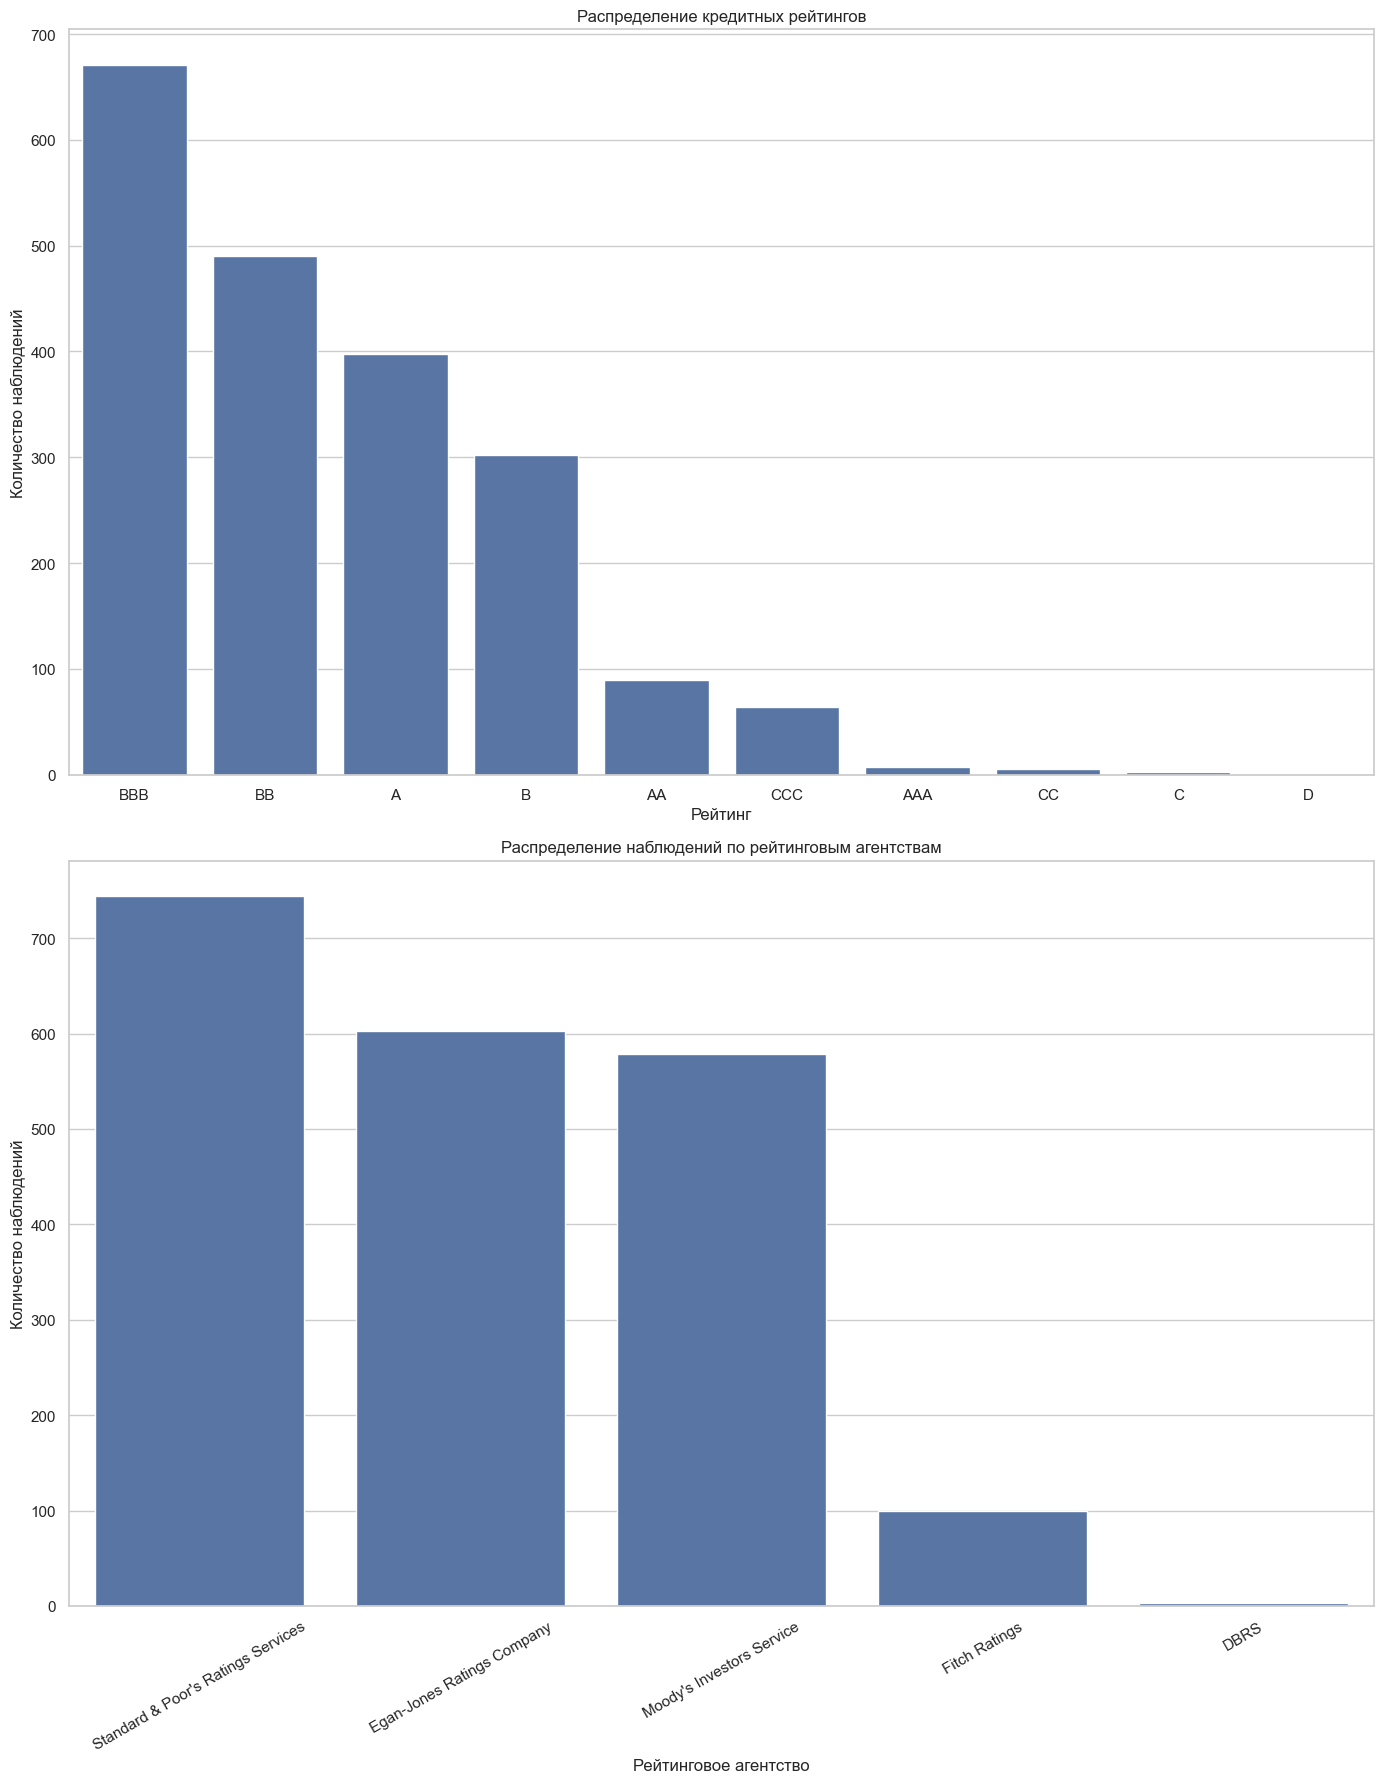

In [174]:
fig, axes = plt.subplots(2, 1, figsize=(14, 18))

rating_order = df["Rating"].value_counts().index
sns.countplot(data=df, x="Rating", order=rating_order, ax=axes[0])
axes[0].set_title("Распределение кредитных рейтингов")
axes[0].set_xlabel("Рейтинг")
axes[0].set_ylabel("Количество наблюдений")

agency_order = df["Rating Agency Name"].value_counts().index
sns.countplot(data=df, x="Rating Agency Name", order=agency_order, ax=axes[1])
axes[1].set_title("Распределение наблюдений по рейтинговым агентствам")
axes[1].set_xlabel("Рейтинговое агентство")
axes[1].set_ylabel("Количество наблюдений")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Обратимся к таблице, предоставленной на сайте Investopedia. Опираясь на нее сгруппируем данные по инвестиционным категориям.

<div align="center">
<img src="data/photos/MajorBondRatings.png" width="500">
</div>

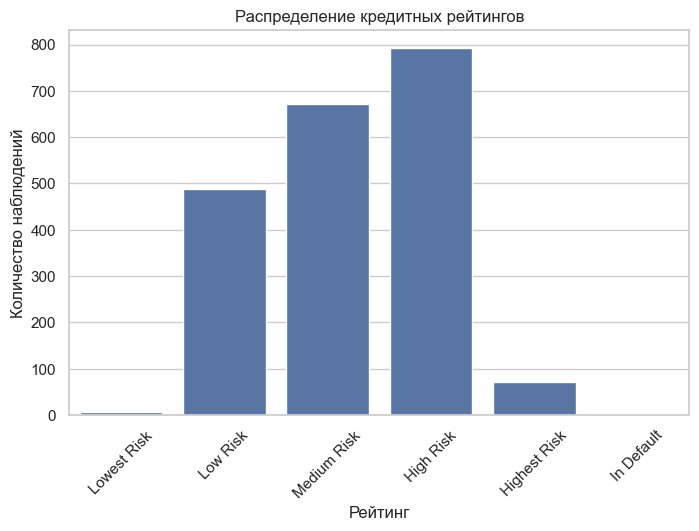

In [175]:
rating_dict = {'AAA':'Lowest Risk', 
               'AA':'Low Risk',
               'A':'Low Risk',
               'BBB':'Medium Risk', 
               'BB':'High Risk',
               'B':'High Risk',
               'CCC':'Highest Risk', 
               'CC':'Highest Risk',
               'C':'Highest Risk',
               'D':'In Default'}

df["RatingGroup"] = df["Rating"].map(rating_dict)

risk_order = [
    "Lowest Risk",
    "Low Risk",
    "Medium Risk",
    "High Risk",
    "Highest Risk",
    "In Default"
]

df = df.drop(columns="Rating")

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x="RatingGroup", order=risk_order, ax=ax)

ax.set_title("Распределение кредитных рейтингов")
ax.set_xlabel("Рейтинг")
ax.set_ylabel("Количество наблюдений")
ax.tick_params(axis="x", rotation=45)

plt.show()

Удалим категории **In Default** и **Lowest Risk**, так как они слишком малочисленны и будем работать с остальными.

In [176]:
df = df[~df["RatingGroup"].isin(["Lowest Risk", "In Default"])]
df.reset_index(inplace = True, drop=True)

## Предобработка данных

Сохраним исходный размер выборки и выделим числовые признаки из текущего датафрейма `df`.

In [177]:
preprocessing_shape_before = df.shape
numeric_features = df.select_dtypes(include=["number"]).columns.tolist()

print(f"Размер df до предобработки: {preprocessing_shape_before}")
print(f"Количество числовых признаков: {len(numeric_features)}")
numeric_features

Размер df до предобработки: (2021, 31)
Количество числовых признаков: 25


['currentRatio',
 'quickRatio',
 'cashRatio',
 'daysOfSalesOutstanding',
 'netProfitMargin',
 'pretaxProfitMargin',
 'grossProfitMargin',
 'operatingProfitMargin',
 'returnOnAssets',
 'returnOnCapitalEmployed',
 'returnOnEquity',
 'assetTurnover',
 'fixedAssetTurnover',
 'debtEquityRatio',
 'debtRatio',
 'effectiveTaxRate',
 'freeCashFlowOperatingCashFlowRatio',
 'freeCashFlowPerShare',
 'cashPerShare',
 'companyEquityMultiplier',
 'ebitPerRevenue',
 'enterpriseValueMultiple',
 'operatingCashFlowPerShare',
 'operatingCashFlowSalesRatio',
 'payablesTurnover']

Посмотрим распределение числовых признаков до winsorization, чтобы увидеть масштаб выбросов.

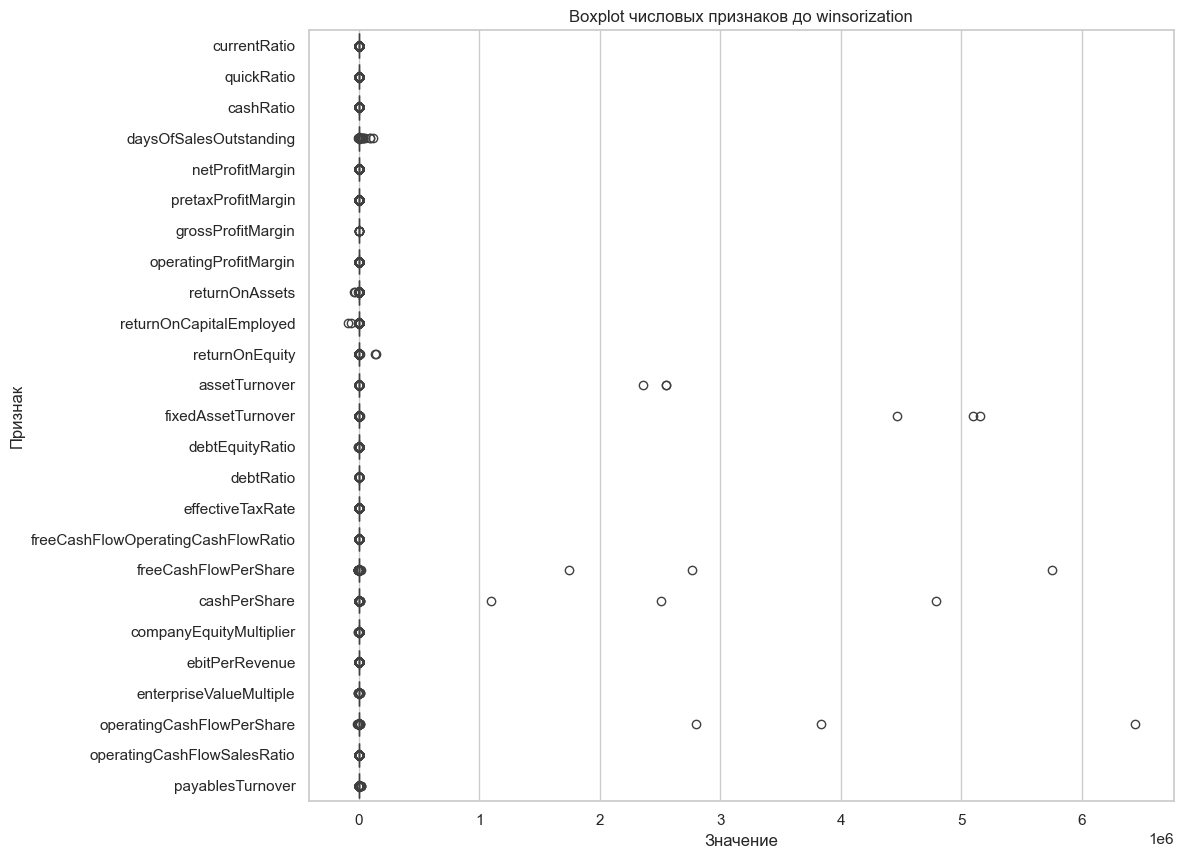

In [178]:
plt.figure(figsize=(12, max(6, 0.35 * len(numeric_features))))
sns.boxplot(data=df[numeric_features], orient="h", color="#4c78a8")
plt.title("Boxplot числовых признаков до winsorization")
plt.xlabel("Значение")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

Для нескольких наиболее вариативных признаков посмотрим распределения до обработки выбросов.

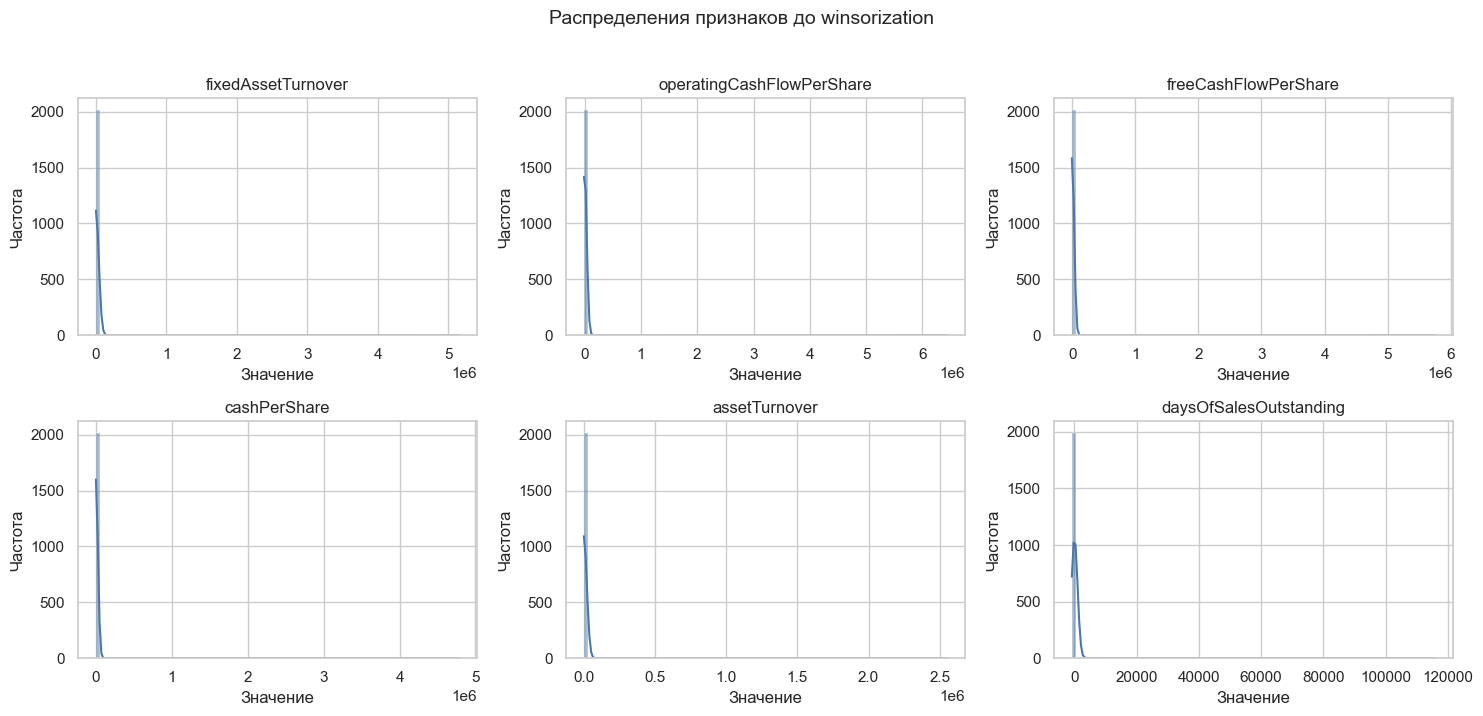

In [179]:
distribution_features = []

distribution_features = (
    df[numeric_features]
    .var(numeric_only=True)
    .sort_values(ascending=False)
    .head(min(6, len(numeric_features)))
    .index
    .tolist()
)

n_cols = min(3, len(distribution_features))
n_rows = int(np.ceil(len(distribution_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, distribution_features):
    sns.histplot(df[feature], kde=True, ax=ax, color="#4c78a8")
    ax.set_title(feature)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Частота")

for ax in axes[len(distribution_features):]:
    ax.set_visible(False)

fig.suptitle("Распределения признаков до winsorization", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Оценим асимметрию числовых признаков до обработки выбросов.

,skewness_before
currentRatio,34.271115
cashPerShare,33.958646
freeCashFlowPerShare,33.610677
returnOnCapitalEmployed,-33.252701
effectiveTaxRate,32.265705
returnOnAssets,-32.049111
returnOnEquity,31.639845
quickRatio,30.864610
operatingCashFlowPerShare,30.292914
cashRatio,27.046952


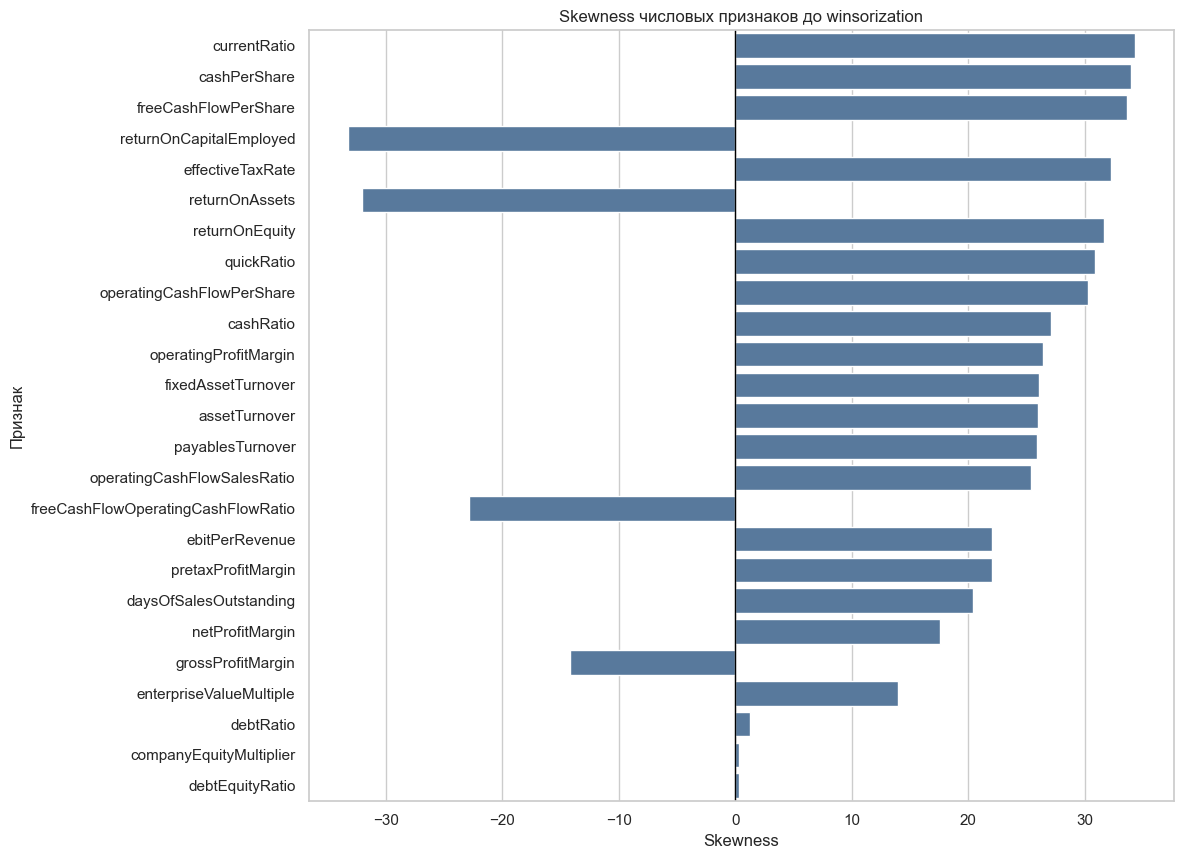

In [180]:
if numeric_features:
    skewness_before = df[numeric_features].skew()
    skewness_before = skewness_before.reindex(skewness_before.abs().sort_values(ascending=False).index)
    display(skewness_before.to_frame("skewness_before"))

    plt.figure(figsize=(12, max(6, 0.35 * len(skewness_before))))
    sns.barplot(x=skewness_before.values, y=skewness_before.index, color="#4c78a8")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Skewness числовых признаков до winsorization")
    plt.xlabel("Skewness")
    plt.ylabel("Признак")
    plt.tight_layout()
    plt.show()
else:
    skewness_before = pd.Series(dtype=float)
    print("Числовые признаки не найдены.")

Большинство числовых признаков имеет сильную асимметрию распределения. У многих показателей асимметрия значительно больше нуля, что говорит о длинном правом хвосте и наличии очень больших выбросов.

Данные содержат выраженные выбросы и несимметричные распределения. Поэтому перед обучением моделей необходимо ограничить экстремальные значения с помощью winsorization и затем масштабировать признаки.

Чтобы избежать утечки информации из тестовой выборки, фактическую winsorization и масштабирование выполним только после формирования `X`, `y` и разбиения на train/test. Квантили и параметры scaler будут рассчитываться только по обучающей выборке.

### Обработка категориальных признаков

Удалим идентификаторы компаний Name, Rating Agency Name и Symbol, так как они не должны использоваться как признаки модели.

In [181]:
identifier_columns = [column for column in ["Name", "Rating Agency Name", "Symbol"] if column in df.columns]

df.drop(columns=identifier_columns, inplace=True)

Преобразуем признак Date в год и удалим исходный столбец даты.

In [182]:
date_values = df["Date"]

if pd.api.types.is_numeric_dtype(date_values):
    date_values = date_values.astype("Int64").astype(str)

df["Year"] = pd.to_datetime(date_values, errors="coerce").dt.year
df.drop(columns=["Date"], inplace=True)

Закодируем Sector через One-Hot Encoding, потому что у этих категорий нет естественного порядка.

In [183]:
df = pd.get_dummies(df, columns=["Sector"], drop_first=False)

Закодируем целевую переменную RatingGroup вручную, сохранив смысловой порядок кредитного риска.

In [184]:
rating_group_mapping = {
    "Low Risk": 0,
    "Medium Risk": 1,
    "High Risk": 2,
    "Highest Risk": 3
}

unexpected_rating_groups = sorted(
    set(df["RatingGroup"].dropna().unique()) - set(rating_group_mapping.keys())
    )
df["RatingGroup"] = df["RatingGroup"].map(rating_group_mapping)

rating_group_mapping

{'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2, 'Highest Risk': 3}

Посмотрим первые строки итогового датафрейма после кодирования категориальных признаков.

In [185]:
display(df.head())

,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,Sector_Consumer Durables,Sector_Consumer Non-Durables,Sector_Consumer Services,Sector_Energy,Sector_Finance,Sector_Health Care,Sector_Miscellaneous,Sector_Public Utilities,Sector_Technology,Sector_Transportation
0,0.945894,0.426395,0.099690,44.203245,0.037480,0.049351,0.176631,0.061510,0.041189,0.091514,...,True,False,False,False,False,False,False,False,False,False
1,1.033559,0.498234,0.203120,38.991156,0.044062,0.048857,0.175715,0.066546,0.053204,0.104800,...,True,False,False,False,False,False,False,False,False,False
2,0.963703,0.451505,0.122099,50.841385,0.032709,0.044334,0.170843,0.059783,0.032497,0.075955,...,True,False,False,False,False,False,False,False,False,False
3,1.019851,0.510402,0.176116,41.161738,0.020894,-0.012858,0.138059,0.042430,0.025690,-0.027015,...,True,False,False,False,False,False,False,False,False,False
4,0.957844,0.495432,0.141608,47.761126,0.042861,0.053770,0.177720,0.065354,0.046363,0.096945,...,True,False,False,False,False,False,False,False,False,False


Разделим данные на матрицу признаков X и целевую переменную y.

In [186]:
X = df.drop(columns=["RatingGroup"])
y = df["RatingGroup"]

### Разделение данных

Сразу после формирования X и y разделим данные на обучающую и тестовую выборки со стратификацией.

In [187]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (1616, 38)
Размер тестовой выборки: (405, 38)


### Предобработка train/test

Определим числовые признаки для обработки и отдельно сохраним one-hot признаки, которые не нужно масштабировать.

In [188]:
X_train = X_train.copy()
X_test = X_test.copy()

one_hot_features = [column for column in X_train.columns if column.startswith("Sector_")]
numeric_features = [
    column
    for column in X_train.select_dtypes(include=["number"]).columns
    if column not in one_hot_features
]
categorical_features = one_hot_features

Выполним winsorization без утечки: границы 1% и 99% считаются только на X_train, после чего те же границы применяются к X_test.

In [189]:
X_train[numeric_features] = X_train[numeric_features].astype(float)
X_test[numeric_features] = X_test[numeric_features].astype(float)

quantile_bounds = X_train[numeric_features].quantile([0.01, 0.99])

for feature in numeric_features:
    lower_bound = quantile_bounds.loc[0.01, feature]
    upper_bound = quantile_bounds.loc[0.99, feature]

    X_train[feature] = X_train[feature].clip(lower=lower_bound, upper=upper_bound)
    X_test[feature] = X_test[feature].clip(lower=lower_bound, upper=upper_bound)

X_train_after_winsorization = X_train.copy()
X_test_after_winsorization = X_test.copy()

Посмотрим распределения выбранных числовых признаков после winsorization на обучающей выборке.

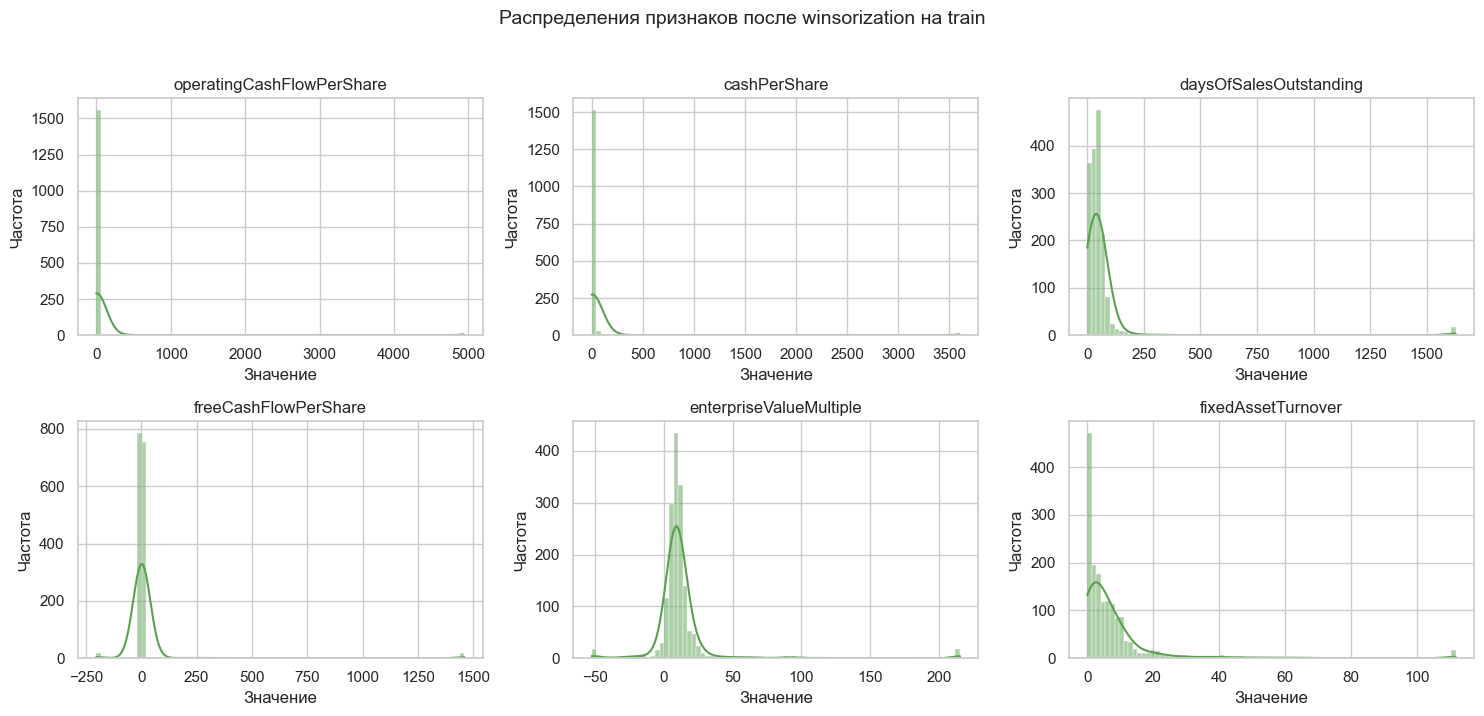

In [190]:
distribution_features = (
    X_train_after_winsorization[numeric_features]
    .var(numeric_only=True)
    .sort_values(ascending=False)
    .head(min(6, len(numeric_features)))
    .index
    .tolist()
)

n_cols = min(3, len(distribution_features))
n_rows = int(np.ceil(len(distribution_features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, distribution_features):
    sns.histplot(X_train_after_winsorization[feature], kde=True, ax=ax, color="#59a14f")
    ax.set_title(feature)
    ax.set_xlabel("Значение")
    ax.set_ylabel("Частота")

for ax in axes[len(distribution_features):]:
    ax.set_visible(False)

fig.suptitle("Распределения признаков после winsorization на train", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

После winsorization экстремальные значения были ограничены, однако числовые признаки всё еще имеют разные масштабы. Поэтому перед обучением моделей они дополнительно масштабируются с помощью RobustScaler. Чтобы избежать утечки данных, параметры winsorization и RobustScaler рассчитываются только на обучающей выборке, а затем применяются к тестовой выборке.

Масштабируем только числовые признаки с помощью `RobustScaler`; one-hot признаки оставляем без изменений.

In [191]:
scaler = RobustScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

Проверим boxplot числовых признаков после winsorization и RobustScaler.

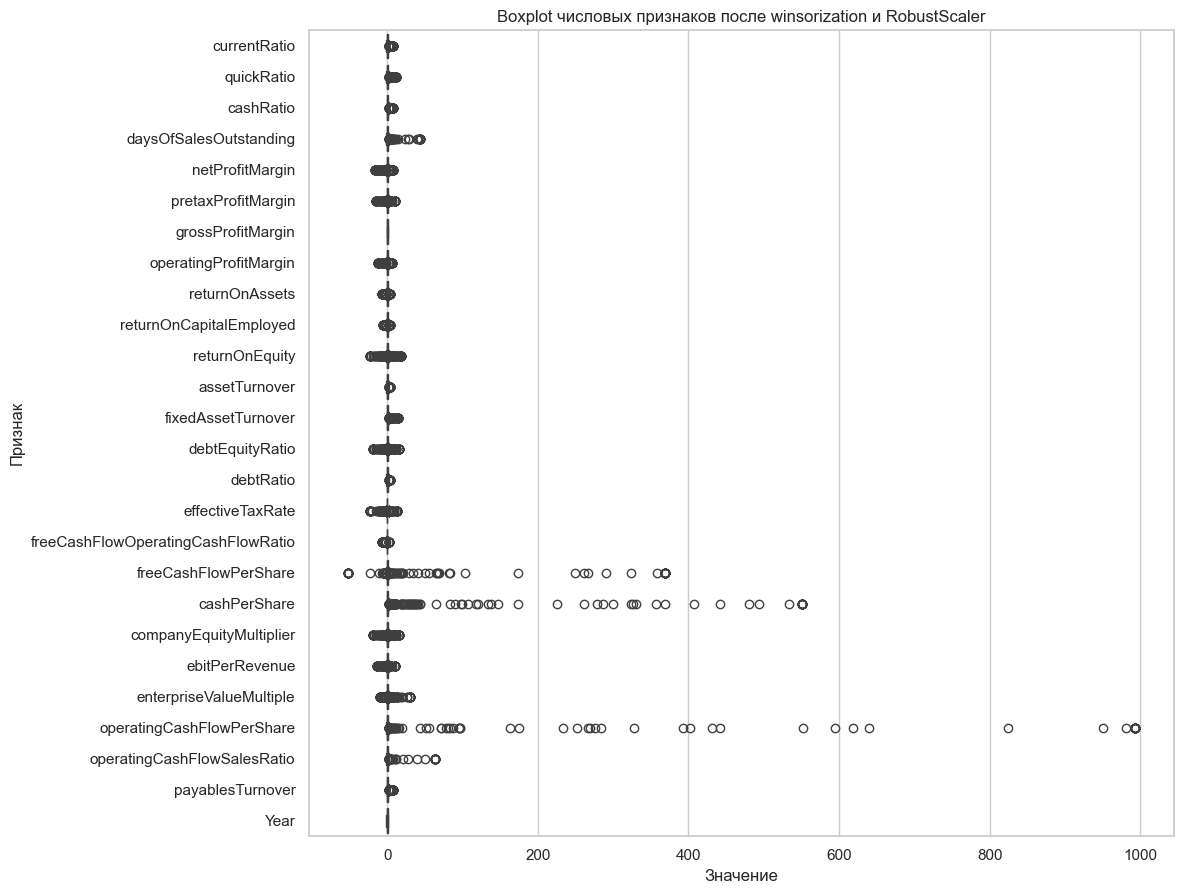

In [192]:
plt.figure(figsize=(12, max(6, 0.35 * len(numeric_features))))
sns.boxplot(data=X_train[numeric_features], orient="h", color="#59a14f")
plt.title("Boxplot числовых признаков после winsorization и RobustScaler")
plt.xlabel("Значение")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

Оценим асимметрию числовых признаков после обработки.

,skewness_after_processing
operatingCashFlowSalesRatio,8.695940
daysOfSalesOutstanding,8.005804
freeCashFlowPerShare,7.822282
operatingCashFlowPerShare,7.675485
cashPerShare,7.158862
enterpriseValueMultiple,5.625733
fixedAssetTurnover,4.896820
quickRatio,3.989505
payablesTurnover,3.399541
currentRatio,3.348201


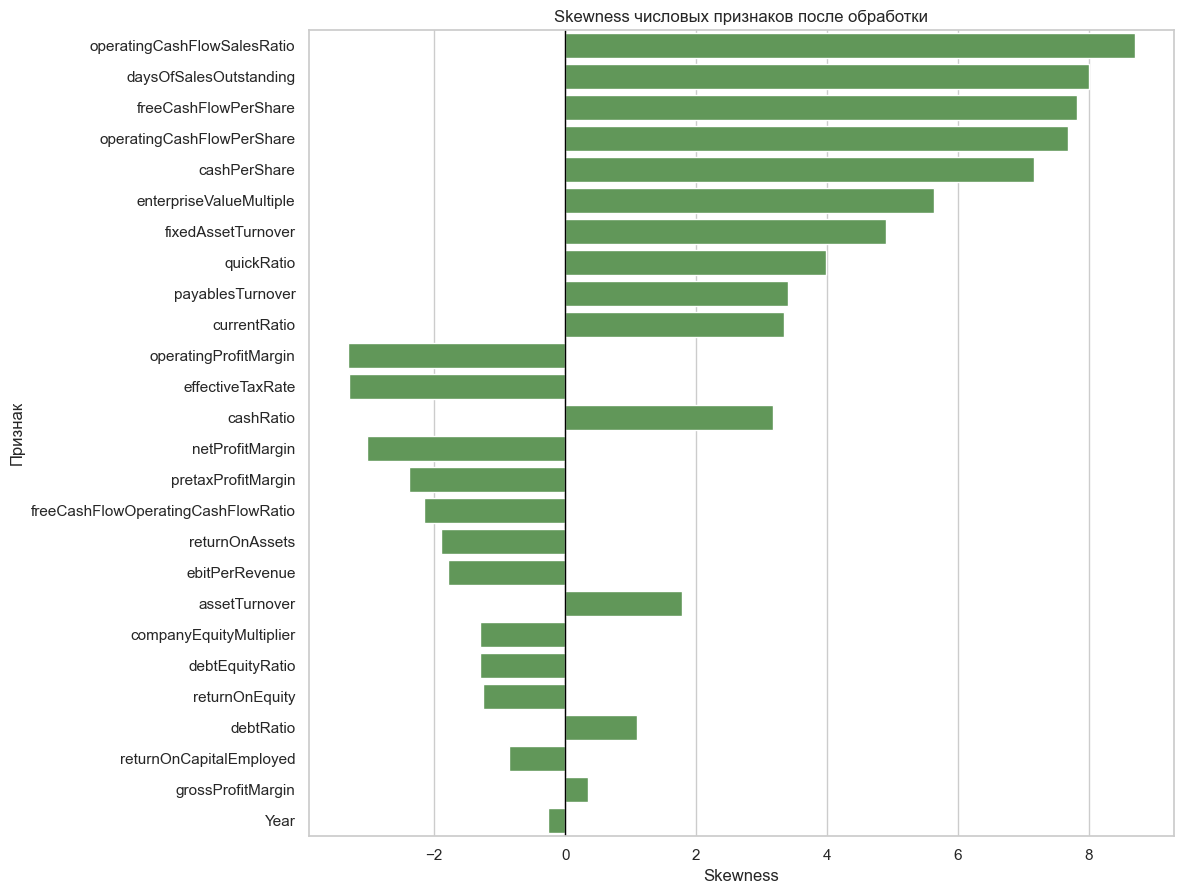

In [193]:
if numeric_features:
    skewness_after_processing = X_train[numeric_features].skew()
    skewness_after_processing = skewness_after_processing.reindex(
        skewness_after_processing.abs().sort_values(ascending=False).index
    )
    display(skewness_after_processing.to_frame("skewness_after_processing"))

    plt.figure(figsize=(12, max(6, 0.35 * len(skewness_after_processing))))
    sns.barplot(x=skewness_after_processing.values, y=skewness_after_processing.index, color="#59a14f")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Skewness числовых признаков после обработки")
    plt.xlabel("Skewness")
    plt.ylabel("Признак")
    plt.tight_layout()
    plt.show()
else:
    print("Числовые признаки не найдены.")

Ассиметрия стала в разы меньше, но все еще присутствует.

### Базовые модели

Для сравнения были выбраны несколько моделей, часто используемых в задачах прогнозирования кредитных рейтингов и классификации финансовых данных. В литературе по данной теме обычно рассматриваются как классические статистические модели, так и методы машинного обучения: логистическая регрессия, деревья решений, ансамблевые методы, градиентный бустинг, SVM и KNN.

In [194]:
class_names = ["Low Risk", "Medium Risk", "High Risk", "Highest Risk"]
class_labels = list(range(len(class_names)))

models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
}

pd.DataFrame({"model": list(models.keys())})

,model
0,Dummy Baseline
1,Logistic Regression
2,XGBoost
3,Decision Tree
4,Random Forest
5,Gradient Boosting
6,SVM
7,KNN


### Базовое обучение и оценка

##### Метрики качества моделей

Для оценки качества моделей используется несколько метрик, так как задача является многоклассовой, а распределение рейтинговых групп несбалансировано.

* **Accuracy** показывает общую долю правильных предсказаний. Это простая базовая метрика, но при дисбалансе классов она может быть недостаточно информативной.

* **Balanced accuracy** учитывает качество предсказаний по каждому классу отдельно и затем усредняет результат. Эта метрика полезна, так как одни рейтинговые группы встречаются чаще других.

* **Macro F1** считается отдельно для каждого класса, а затем усредняется без учета размера классов. Поэтому эта метрика показывает, насколько хорошо модель работает не только на частых, но и на редких рейтинговых группах.

* **Weighted F1** также учитывает F1-score по каждому классу, но взвешивает их по количеству объектов в классе. Она показывает качество модели с учетом реального распределения данных.

* **Mean Absolute Error** используется потому, что рейтинговые группы имеют порядок риска. Эта метрика показывает, насколько далеко в среднем предсказанный класс находится от истинного по шкале рейтинга.


В качестве основной метрики качества выбрана macro F1, так как мы имеем очень несбалансированное распределение рейтинговых групп. Эта метрика с одинаковым влиянием учитывает качество предсказания каждого класса, поэтому позволяет оценить, насколько модель справляется не только с наиболее частыми, но и с редкими рейтинговыми группами.

c:\Users\Fedor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


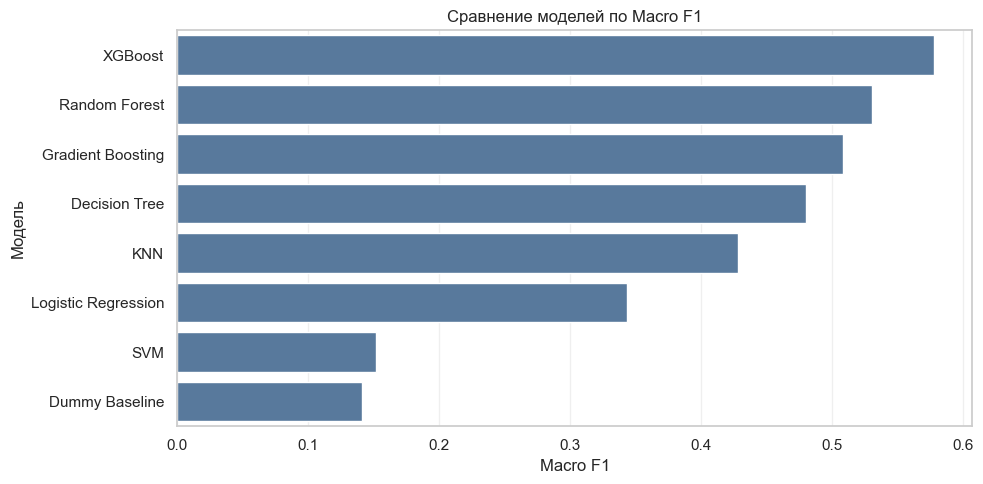

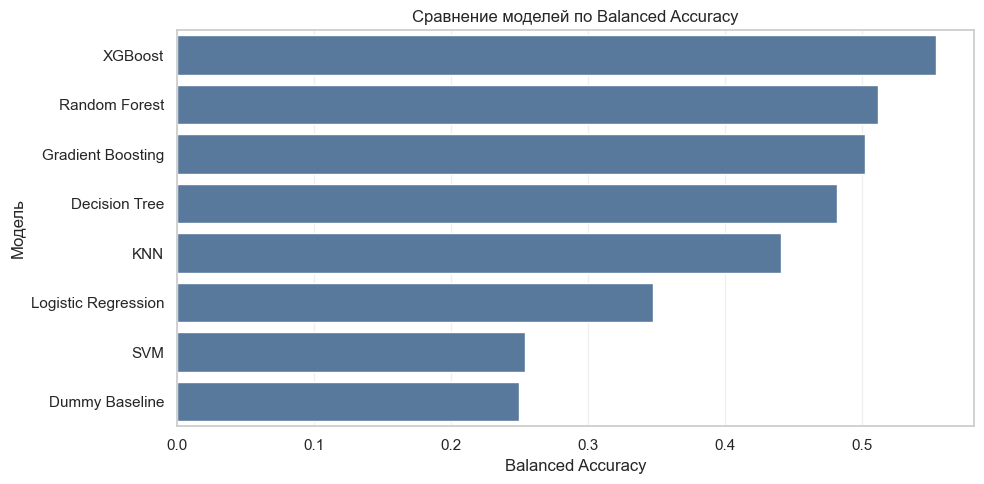

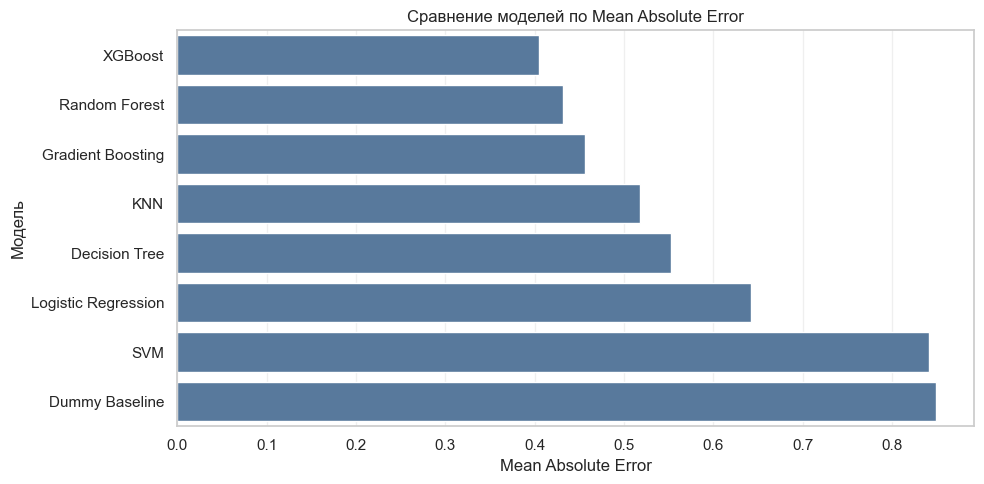

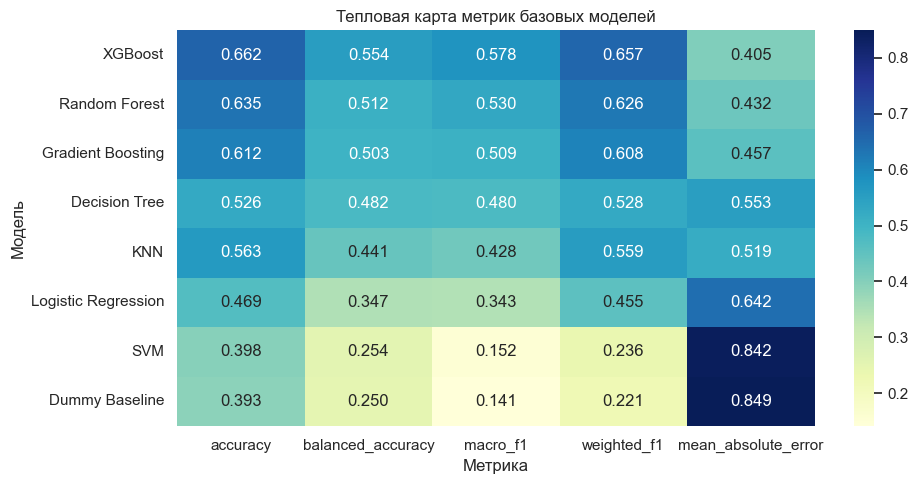

In [195]:
results = []
fitted_models = {}
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    fitted_models[model_name] = model
    predictions[model_name] = y_pred

    model_metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "mean_absolute_error": mean_absolute_error(y_test, y_pred),
    }
    model_metrics["model"] = model_name
    results.append(model_metrics)

results_df = (
    pd.DataFrame(results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

plot_metrics = [
    ("macro_f1", "Macro F1", False),
    ("balanced_accuracy", "Balanced Accuracy", False),
    ("mean_absolute_error", "Mean Absolute Error", True),
]

for metric, title, ascending in plot_metrics:
    plot_df = results_df.sort_values(metric, ascending=ascending)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x=metric, y="model", color="#4C78A8")
    plt.title(f"Сравнение моделей по {title}")
    plt.xlabel(title)
    plt.ylabel("Модель")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

heatmap_df = results_df.set_index("model")[
    ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "mean_absolute_error"]
]

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Тепловая карта метрик базовых моделей")
plt.xlabel("Метрика")
plt.ylabel("Модель")
plt.tight_layout()
plt.show()

##### Вывод по результатам моделей

Лучшее качество на тестовой выборке показала модель **XGBoost**. Она имеет наибольшее значение основной метрики macro F1 — около **0.578**, а также минимальное значение MAE — около **0.405**.

Таким образом, на данном этапе наиболее сильной базовой моделью является **XGBoost**. Random Forest и Gradient Boosting остаются ближайшими конкурентами, поэтому все три модели целесообразно оставить для дальнейшего подбора гиперпараметров.

### Кросс-валидация

Проверим устойчивость качества моделей через StratifiedKFold и метрику f1_macro на обработанной обучающей выборке.

c:\Users\Fedor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Fedor\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

,model,cv_macro_f1_mean,cv_macro_f1_std
0,XGBoost,0.542634,0.021221
1,Random Forest,0.527516,0.024555
2,Gradient Boosting,0.501560,0.027352
3,KNN,0.451943,0.030509
4,Decision Tree,0.422111,0.056198
5,Logistic Regression,0.375126,0.031392
6,SVM,0.156868,0.003295
7,Dummy Baseline,0.140729,0.000478


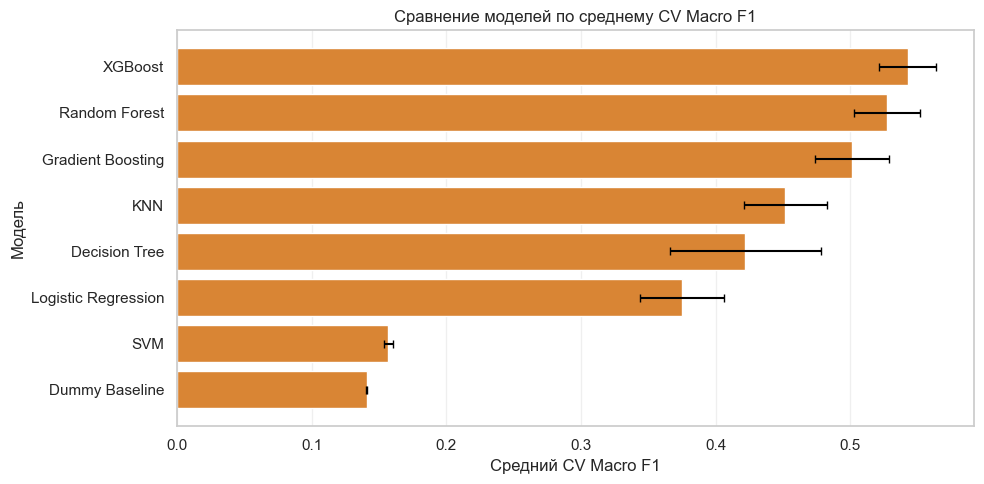

In [196]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
    )

    cv_results.append({
        "model": model_name,
        "cv_macro_f1_mean": scores.mean(),
        "cv_macro_f1_std": scores.std(),
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("cv_macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_results_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x="cv_macro_f1_mean", y="model", color="#F58518")
plt.errorbar(
    cv_results_df["cv_macro_f1_mean"],
    cv_results_df["model"],
    xerr=cv_results_df["cv_macro_f1_std"],
    fmt="none",
    ecolor="black",
    capsize=3,
)
plt.title("Сравнение моделей по среднему CV Macro F1")
plt.xlabel("Средний CV Macro F1")
plt.ylabel("Модель")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

По результатам кросс-валидации на обработанной обучающей выборке наиболее устойчивой и качественной моделью является **XGBoost**. Она показала наибольшее среднее значение Macro F1 — около **0.543**, при стандартном отклонении около **0.021**.

Для дальнейшего подбора гиперпараметров целесообразно выбрать три лучшие модели по кросс-валидации: **XGBoost**, **Random Forest** и **Gradient Boosting**.

### Подбор гиперпараметров

Для трех лучших моделей — XGBoost, Random Forest и Gradient Boosting — выполняется подбор гиперпараметров с помощью Optuna. В качестве основной метрики используется macro F1, так как классы рейтингов несбалансированы. Подбор проводится на обработанной обучающей выборке с использованием кросс-валидации, после чего качество лучших моделей проверяется на обработанной тестовой выборке.

In [197]:
N_TRIALS = 50

optuna_results = []
tuned_models = {}
tuned_predictions = {}

study_rf = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

for _ in range(N_TRIALS):
    trial = study_rf.ask()

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_categorical("max_depth", [None, 5, 10, 15, 20]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"])
    }

    model = RandomForestClassifier(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    study_rf.tell(trial, scores.mean())

print("Random Forest")
print("Лучший CV Macro F1:", round(study_rf.best_value, 4))
print("Лучшие параметры:", study_rf.best_params)

# Подбор гиперпараметров для Gradient Boosting

study_gb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

for _ in range(N_TRIALS):
    trial = study_gb.ask()

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0)
    }

    model = GradientBoostingClassifier(
        **params,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    study_gb.tell(trial, scores.mean())

print("Gradient Boosting")
print("Лучший CV Macro F1:", round(study_gb.best_value, 4))
print("Лучшие параметры:", study_gb.best_params)

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE)
)

for _ in range(N_TRIALS):
    trial = study_xgb.ask()

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0)
    }

    model = XGBClassifier(
        **params,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    study_xgb.tell(trial, scores.mean())

print("XGBoost")
print("Лучший CV Macro F1:", round(study_xgb.best_value, 4))
print("Лучшие параметры:", study_xgb.best_params)

best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

rf_metrics = {
    "model": "Random Forest",
    "best_cv_macro_f1": study_rf.best_value,
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "macro_f1": f1_score(y_test, y_pred_rf, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_rf, average="weighted", zero_division=0),
    "mean_absolute_error": mean_absolute_error(y_test, y_pred_rf),
    "best_params": study_rf.best_params
}

tuned_models["Random Forest"] = best_rf
tuned_predictions["Random Forest"] = y_pred_rf
optuna_results.append(rf_metrics)

best_gb = GradientBoostingClassifier(
    **study_gb.best_params,
    random_state=RANDOM_STATE
)

best_gb.fit(X_train, y_train)
y_pred_gb = best_gb.predict(X_test)

gb_metrics = {
    "model": "Gradient Boosting",
    "best_cv_macro_f1": study_gb.best_value,
    "accuracy": accuracy_score(y_test, y_pred_gb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_gb),
    "macro_f1": f1_score(y_test, y_pred_gb, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_gb, average="weighted", zero_division=0),
    "mean_absolute_error": mean_absolute_error(y_test, y_pred_gb),
    "best_params": study_gb.best_params
}

tuned_models["Gradient Boosting"] = best_gb
tuned_predictions["Gradient Boosting"] = y_pred_gb
optuna_results.append(gb_metrics)

best_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)

xgb_metrics = {
    "model": "XGBoost",
    "best_cv_macro_f1": study_xgb.best_value,
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_xgb),
    "macro_f1": f1_score(y_test, y_pred_xgb, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_xgb, average="weighted", zero_division=0),
    "mean_absolute_error": mean_absolute_error(y_test, y_pred_xgb),
    "best_params": study_xgb.best_params
}

tuned_models["XGBoost"] = best_xgb
tuned_predictions["XGBoost"] = y_pred_xgb
optuna_results.append(xgb_metrics)

tuning_results_df = (
    pd.DataFrame(optuna_results)
    .sort_values("best_cv_macro_f1", ascending=False)
    .reset_index(drop=True)
)

tuning_results_df

best_model_name = tuning_results_df.loc[0, "model"]
best_model = tuned_models[best_model_name]
best_y_pred = tuned_predictions[best_model_name]

print(f"Лучшая модель после Optuna: {best_model_name}")
print(f"CV Macro F1: {tuning_results_df.loc[0, 'best_cv_macro_f1']:.4f}")
print(f"Test Macro F1: {tuning_results_df.loc[0, 'macro_f1']:.4f}")
print(f"Test Accuracy: {tuning_results_df.loc[0, 'accuracy']:.4f}")
print(f"Test Balanced Accuracy: {tuning_results_df.loc[0, 'balanced_accuracy']:.4f}")
print(f"Test MAE: {tuning_results_df.loc[0, 'mean_absolute_error']:.4f}")

[I 2026-06-03 16:39:21,092] A new study created in memory with name: no-name-766cdf78-b1cd-4273-b438-b4c57359cddb


[I 2026-06-03 16:40:24,517] A new study created in memory with name: no-name-43e777fe-614d-4fdb-a9e3-077329bfff4e


Random Forest
Лучший CV Macro F1: 0.5434
Лучшие параметры: {'n_estimators': 442, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}


[I 2026-06-03 16:48:13,452] A new study created in memory with name: no-name-ae59a935-761d-4d6d-bfdc-bc866a8359ed


Gradient Boosting
Лучший CV Macro F1: 0.5792
Лучшие параметры: {'n_estimators': 289, 'learning_rate': 0.10834792557872462, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 5, 'subsample': 0.8128313920642372}
XGBoost
Лучший CV Macro F1: 0.5741
Лучшие параметры: {'n_estimators': 216, 'learning_rate': 0.1639398719414773, 'max_depth': 5, 'min_child_weight': 8, 'subsample': 0.9623951395132709, 'colsample_bytree': 0.9416896356045592, 'reg_lambda': 0.33956553799610445, 'reg_alpha': 0.8246820804479891}
Лучшая модель после Optuna: Gradient Boosting
CV Macro F1: 0.5792
Test Macro F1: 0.5596
Test Accuracy: 0.6741
Test Balanced Accuracy: 0.5466
Test MAE: 0.3926


Лучшей моделью после подбора гиперпараметров стал градиентный бустинг. Оценим ее на обработанной тестовой выборке.

In [198]:
best_model_name = tuning_results_df.loc[0, "model"]
best_params = tuning_results_df.loc[0, "best_params"]
best_cv_macro_f1 = tuning_results_df.loc[0, "best_cv_macro_f1"]

best_model = tuned_models[best_model_name]
best_y_pred = tuned_predictions[best_model_name]

best_metrics = {
    "accuracy": accuracy_score(y_test, best_y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, best_y_pred),
    "macro_f1": f1_score(y_test, best_y_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, best_y_pred, average="weighted", zero_division=0),
    "mean_absolute_error": mean_absolute_error(y_test, best_y_pred),
}

baseline_best = results_df.iloc[0]
macro_f1_diff = best_metrics["macro_f1"] - baseline_best["macro_f1"]
balanced_accuracy_diff = best_metrics["balanced_accuracy"] - baseline_best["balanced_accuracy"]

print(f"Лучшая модель: {best_model_name}")
print(f"Лучшие параметры: {best_params}")
print(f"Лучший CV Macro F1: {best_cv_macro_f1:.4f}")
print()

print(classification_report(
    y_test,
    best_y_pred,
    labels=class_labels,
    target_names=class_names,
    zero_division=0,
))

report_dict = classification_report(
    y_test,
    best_y_pred,
    labels=class_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

class_metrics_df = (
    pd.DataFrame(report_dict)
    .T
    .loc[class_names, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score", ascending=False)
)

best_summary_df = pd.DataFrame([{
    "model": best_model_name,
    "best_cv_macro_f1": best_cv_macro_f1,
    **best_metrics,
    "baseline_best_model": baseline_best["model"],
    "macro_f1_diff_vs_baseline_best": macro_f1_diff,
    "balanced_accuracy_diff_vs_baseline_best": balanced_accuracy_diff,
    "best_params": best_params,
}])

display(best_summary_df)
display(class_metrics_df)

best_classes = class_metrics_df.head(2).index.tolist()
worst_classes = class_metrics_df.tail(2).index.tolist()

print("Лучше всего модель предсказывает классы:", ", ".join(best_classes))
print("Хуже всего модель предсказывает классы:", ", ".join(worst_classes))

Лучшая модель: Gradient Boosting
Лучшие параметры: {'n_estimators': 289, 'learning_rate': 0.10834792557872462, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 5, 'subsample': 0.8128313920642372}
Лучший CV Macro F1: 0.5792

              precision    recall  f1-score   support

    Low Risk       0.65      0.61      0.63        98
 Medium Risk       0.65      0.66      0.66       134
   High Risk       0.71      0.77      0.74       159
Highest Risk       0.40      0.14      0.21        14

    accuracy                           0.67       405
   macro avg       0.60      0.55      0.56       405
weighted avg       0.67      0.67      0.67       405



,model,best_cv_macro_f1,accuracy,balanced_accuracy,macro_f1,weighted_f1,mean_absolute_error,baseline_best_model,macro_f1_diff_vs_baseline_best,balanced_accuracy_diff_vs_baseline_best,best_params
0,Gradient Boosting,0.579211,0.674074,0.546644,0.559631,0.667633,0.392593,XGBoost,-0.01843,-0.007642,"{'n_estimators': 289, 'learning_rate': 0.10834..."


,precision,recall,f1-score,support
High Risk,0.709302,0.767296,0.737160,159.0
Medium Risk,0.654412,0.664179,0.659259,134.0
Low Risk,0.652174,0.612245,0.631579,98.0
Highest Risk,0.400000,0.142857,0.210526,14.0


Лучше всего модель предсказывает классы: High Risk, Medium Risk
Хуже всего модель предсказывает классы: Low Risk, Highest Risk


Построим обычную и нормированную матрицу ошибок для Gradient Boosting.

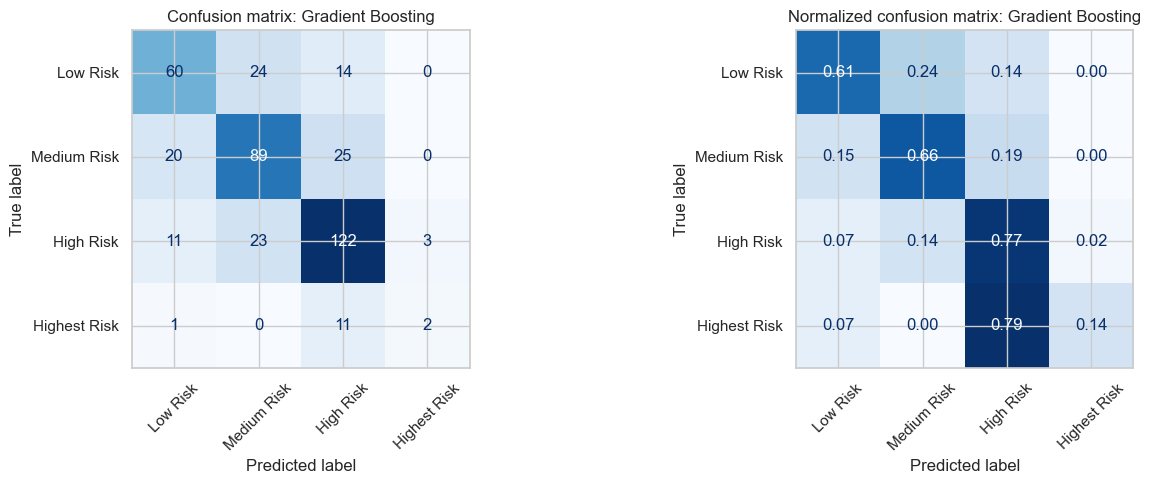

In [199]:
cm = confusion_matrix(y_test, best_y_pred, labels=class_labels)
cm_normalized = confusion_matrix(y_test, best_y_pred, labels=class_labels, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
    ax=axes[0],
    cmap="Blues",
    values_format="d",
    colorbar=False,
)
axes[0].set_title(f"Confusion matrix: {best_model_name}")
axes[0].tick_params(axis="x", rotation=45)

ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names).plot(
    ax=axes[1],
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
)
axes[1].set_title(f"Normalized confusion matrix: {best_model_name}")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Матрица ошибок показала, что градиентный бустинг лучше всего распознает классы среднего и высокого риска. Для класса второго модель правильно классифицировала 122 объекта из 159. Для класса среднего риска правильно определено 89 объектов из 134.

Класс низкого риска также определяется достаточно неплохо: модель верно предсказала 60 объектов из 98. Основные ошибки для этого класса связаны с переходом в средний и высокий риск.

Самая слабая часть модели — класс **Highest Risk**. Из 14 объектов этого класса модель правильно определила только 2. Это очень плохо, так как это самая опасная категория. Это связано с распределением целевой переменной в предоставленном датасете.

В целом модель чаще ошибается между соседними рейтинговыми группами, что является ожидаемым результатом для порядковой задачи. Однако слабое распознавание класса **Highest Risk** остается важным ограничением модели.


### Графики по классам

Сравним precision, recall и f1-score по классам, а также реальные и предсказанные распределения.

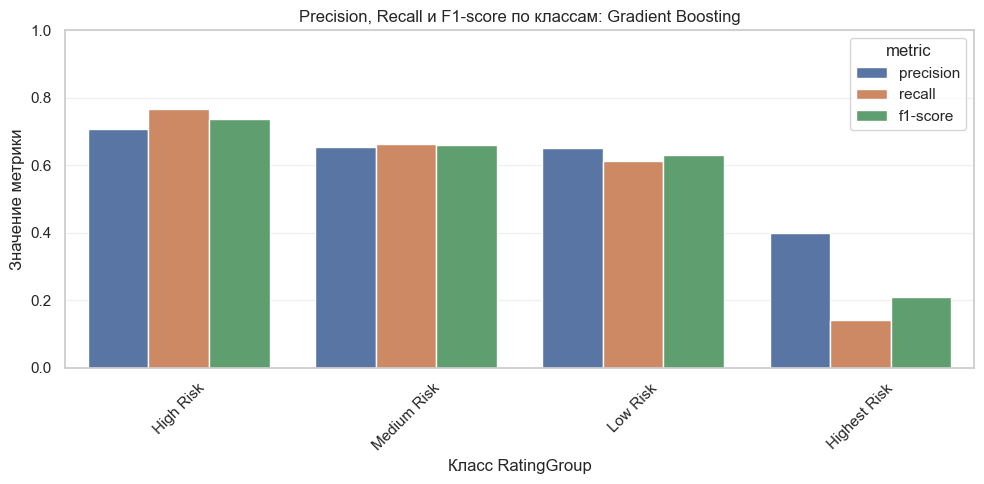

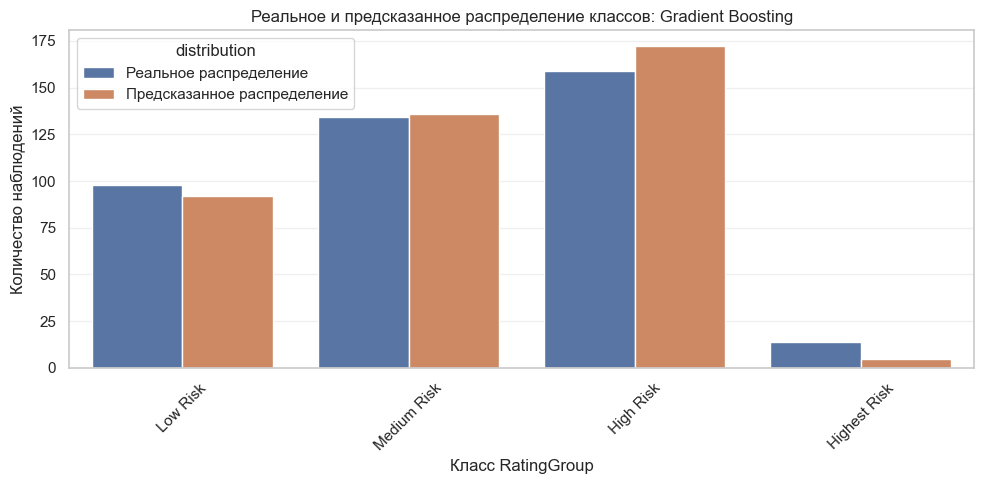

In [200]:
class_metrics_plot_df = (
    class_metrics_df
    .reset_index()
    .rename(columns={"index": "class"})
    .melt(
        id_vars="class",
        value_vars=["precision", "recall", "f1-score"],
        var_name="metric",
        value_name="score",
    )
)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_metrics_plot_df, x="class", y="score", hue="metric")
plt.title(f"Precision, Recall и F1-score по классам: {best_model_name}")
plt.xlabel("Класс RatingGroup")
plt.ylabel("Значение метрики")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

actual_distribution = pd.Series(y_test).value_counts().reindex(class_labels, fill_value=0)
predicted_distribution = pd.Series(best_y_pred).value_counts().reindex(class_labels, fill_value=0)

distribution_df = pd.DataFrame({
    "class": class_names,
    "Реальное распределение": actual_distribution.values,
    "Предсказанное распределение": predicted_distribution.values,
}).melt(id_vars="class", var_name="distribution", value_name="count")

plt.figure(figsize=(10, 5))
sns.barplot(data=distribution_df, x="class", y="count", hue="distribution")
plt.title(f"Реальное и предсказанное распределение классов: {best_model_name}")
plt.xlabel("Класс RatingGroup")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

В целом модель показывает приемлемое качество для основных рейтинговых групп, но плохо справляется с редким классом Highest Risk. Это связано с дисбалансом классов и малым количеством наблюдений в этой категории.


### Важность признаков

После выбора лучшей модели необходимо понять, какие признаки сильнее всего влияют на ее предсказания. Для этого используем два подхода.

**Permutation importance** оценивает важность признака через ухудшение качества модели. Сначала считается качество обученной модели на тестовой выборке. Затем значения одного признака случайно перемешиваются, и качество считается повторно. Если после перемешивания качество сильно падает, значит этот признак был важен для модели.

**Feature importance** использует внутреннюю структуру модели. Для моделей на основе деревьев важность признака рассчитывается по тому, насколько сильно разбиения по этому признаку уменьшают ошибку модели. Чем чаще признак используется в деревьях и чем сильнее он улучшает разделение объектов по классам, тем выше его важность.

##### Permutation importance

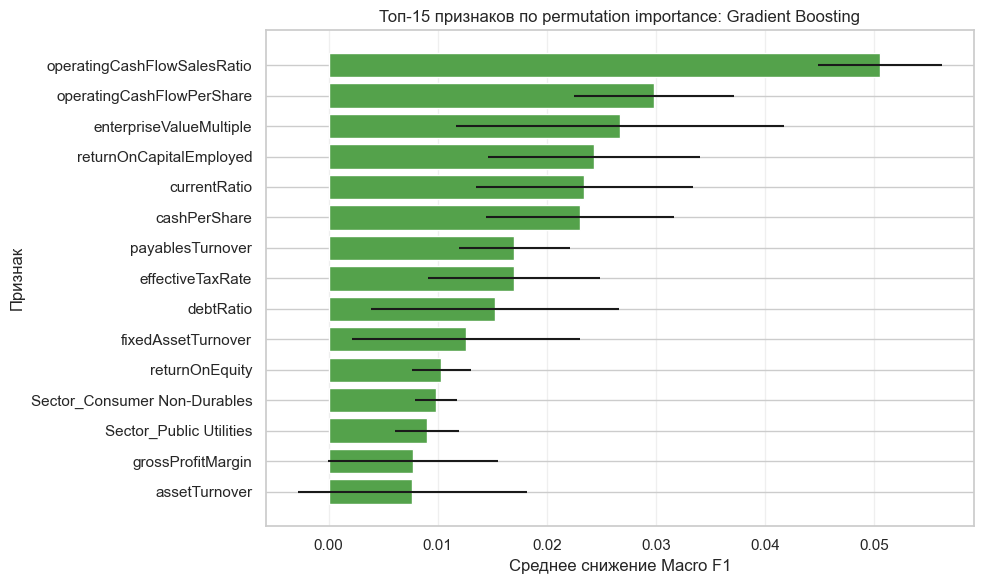

In [201]:
if hasattr(X_train, "columns"):
    feature_names = X_train.columns.astype(str)
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    random_state=RANDOM_STATE,
)

feature_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

top_features_df = feature_importance_df.head(15)
top_features_plot_df = top_features_df.sort_values("importance_mean")

plt.figure(figsize=(10, 6))
plt.barh(
    top_features_plot_df["feature"],
    top_features_plot_df["importance_mean"],
    xerr=top_features_plot_df["importance_std"],
    color="#54A24B",
)
plt.title(f"Топ-15 признаков по permutation importance: {best_model_name}")
plt.xlabel("Среднее снижение Macro F1")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

##### Feature importance

,feature,importance
0,returnOnCapitalEmployed,0.074346
1,operatingCashFlowPerShare,0.066309
2,enterpriseValueMultiple,0.056693
3,returnOnAssets,0.055894
4,operatingCashFlowSalesRatio,0.052668
5,returnOnEquity,0.042683
6,debtRatio,0.042048
7,effectiveTaxRate,0.041874
8,cashRatio,0.040481
9,cashPerShare,0.038971


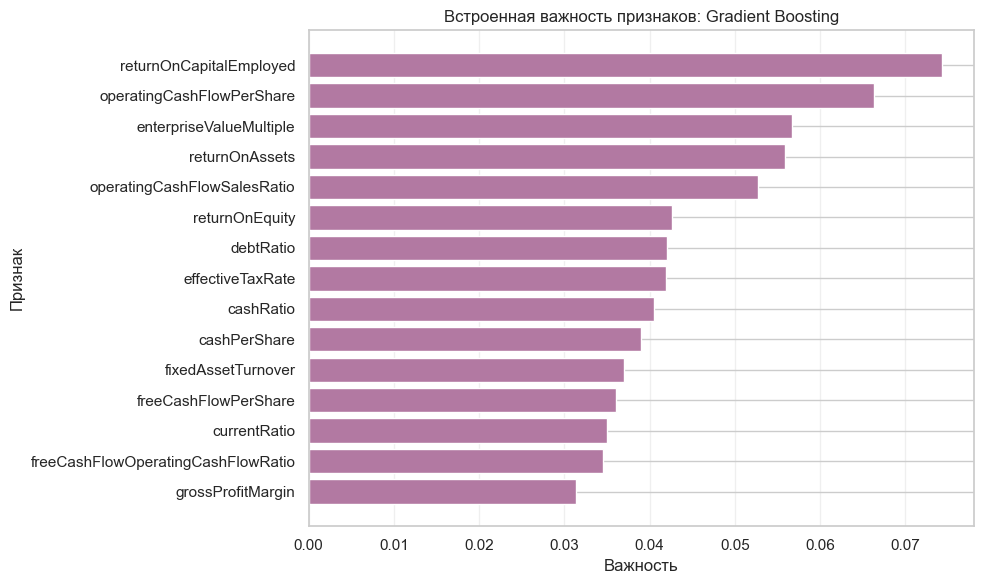

In [202]:
built_in_importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(built_in_importance_df.head(15))

built_in_plot_df = built_in_importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(built_in_plot_df["feature"], built_in_plot_df["importance"], color="#B279A2")
plt.title(f"Встроенная важность признаков: {best_model_name}")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Вывод по важности признаков

Оба метода показывают, что наиболее значимыми для модели являются показатели, связанные с денежными потоками. В обоих методах в топ признаков вошли operatingCashFlowPerShare и operatingCashFlowSalesRatio, отражающие способность генерировать денежный поток.

Модель больше всего опирается на показатели денежныъ потоков. Рассмотрим их предсказание показателя operating_cash_flow на нашем большом датасете.

## II часть. Прогнозирование operatingCashFlowSalesRatio

Во второй части работы рассматривается отдельная ветвь исследования. Стоит задача предсказания финансового показателя, наиболее коррелирующего с инвестиционным рейтингов. Таким коэффициентов по результатом проделанного анализа стал operatingCashFlowSalesRatio, показывающий долю выручки, превращаемую в операционный денежный доход

Сам показатель рассчитывается как отношение операционного денежного дохода к выручке. После расчета эти два исходных столбца нельзя оставлять среди признаков, иначе модель фактически получит прямую подсказку о целевой переменной. Поэтому дальше они используются только для построения целевой переменной.

Импортируем все недостающие библиотеки

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler



Сначала загружается расширенный набор финансовых данных. Посмотрим на размер таблицы, типы столбцов, долю пропусков и распределение наблюдений по компаниям, годам и секторам.


Размер датасета: 33456 строк x 55 столбцов


,ticker,cik,company_name,sector,industry,year,assets,revenue,operating_income,net_income,...,other_noncurrent_liabilities,common_stock_value,operating_lease_rou_asset,operating_lease_liability,operating_lease_liability_current,operating_lease_liability_noncurrent,operating_lease_payments,operating_lease_cost,deferred_tax_assets,deferred_tax_liabilities
0,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2010,9.696000e+09,NaN,5.660000e+08,NaN,...,710000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,501000000.0,293000000.0
1,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2011,9.057000e+09,6.615000e+09,1.071000e+09,NaN,...,643000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,326000000.0,150000000.0
2,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2012,1.053600e+10,6.858000e+09,1.119000e+09,NaN,...,792000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,618000000.0,328000000.0
3,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2013,1.068600e+10,NaN,9.510000e+08,NaN,...,802000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,493000000.0,331000000.0
4,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2014,1.083100e+10,NaN,8.310000e+08,NaN,...,644000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,548000000.0,242000000.0


Типы данных:


,dtype
ticker,str
cik,int64
company_name,str
sector,str
industry,str
year,int64
assets,float64
revenue,float64
operating_income,float64
net_income,float64


Пропуски по столбцам:


,missing_count,missing_share
industry,26624,0.795791
operating_lease_cost,24167,0.722352
operating_lease_payments,23162,0.692312
operating_lease_liability_current,22986,0.687052
operating_lease_liability_noncurrent,22801,0.681522
current_debt,22455,0.671180
long_term_debt,22107,0.660778
revenue,22006,0.657759
operating_lease_liability,21925,0.655338
dividends,21775,0.650855


Уникальных компаний по ticker: 2091


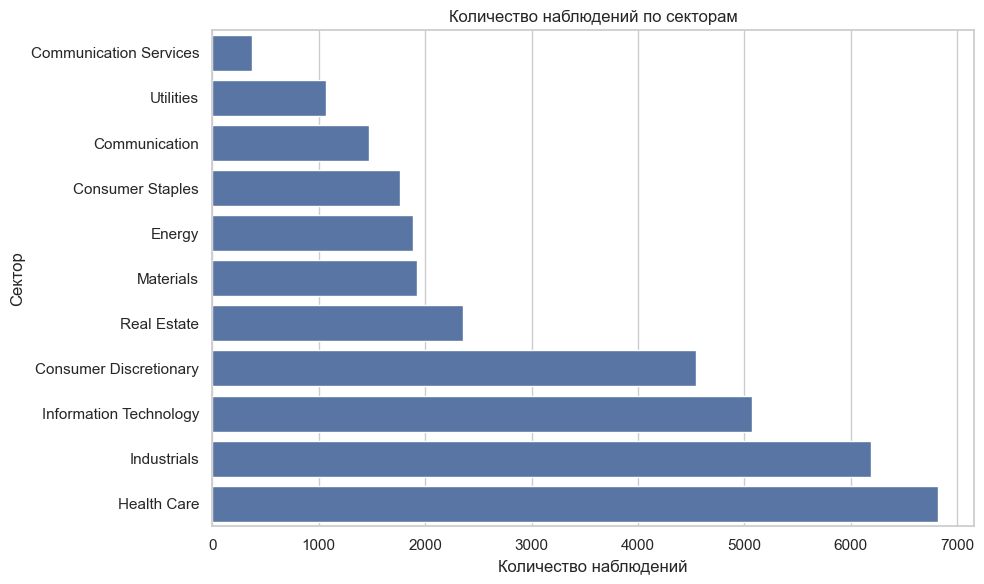

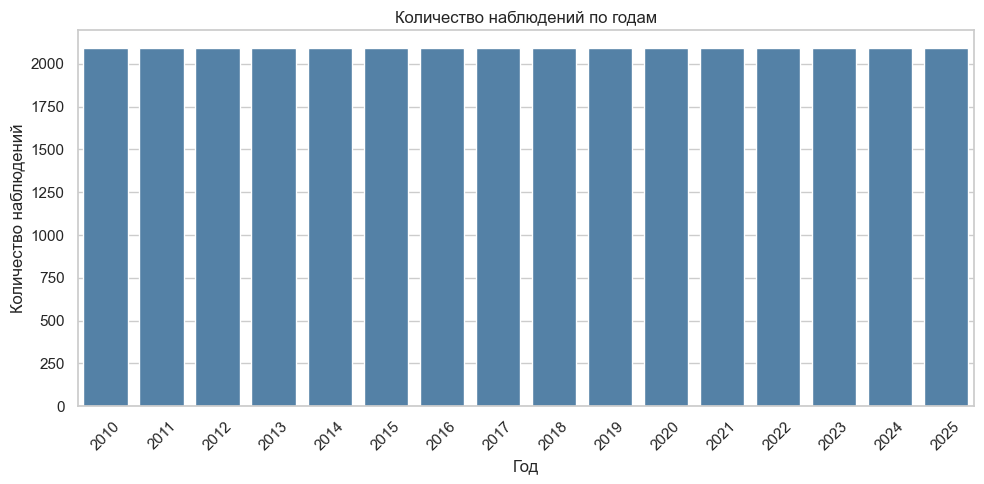

In [204]:
big_df = pd.read_csv("data/sp500_financial_dataset_2010_2025.csv")

print(f"Размер датасета: {big_df.shape[0]} строк x {big_df.shape[1]} столбцов")
display(big_df.head())

print("Типы данных:")
display(big_df.dtypes.to_frame("dtype"))

missing_info = pd.DataFrame({
    "missing_count": big_df.isna().sum(),
    "missing_share": big_df.isna().mean(),
}).sort_values("missing_share", ascending=False)

print("Пропуски по столбцам:")
display(missing_info)

print(f"Уникальных компаний по ticker: {big_df['ticker'].nunique(dropna=True)}")

sector_counts = (
    big_df["sector"]
    .fillna("Unknown")
    .value_counts()
    .sort_values(ascending=True)
    .reset_index()
)
sector_counts.columns = ["sector", "observations"]

plt.figure(figsize=(10, 6))
sns.barplot(data=sector_counts, x="observations", y="sector")
plt.title("Количество наблюдений по секторам")
plt.xlabel("Количество наблюдений")
plt.ylabel("Сектор")
plt.tight_layout()
plt.show()

year_counts = (
    big_df["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)
year_counts.columns = ["year", "observations"]

plt.figure(figsize=(10, 5))
sns.barplot(data=year_counts, x="year", y="observations", color="steelblue")
plt.title("Количество наблюдений по годам")
plt.xlabel("Год")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Эти графики показывают, насколько равномерно представлены разные сектора и годы. Для модели это важно: если часть секторов или периодов заметно доминирует, итоговое качество может лучше отражать именно их поведение, а не всю совокупность компаний.


В данных достаточно много пропущенных значений, особенно в revenue и operating_cash_flow, которые нужны для расчета целевой переменной. Строки, где эти величины отсутствуют или где выручка равна нулю, нельзя использовать для построения operatingCashFlowSalesRatio, поэтому они удаляются до расчета target. Остальные пропуски в признаках пока не заполняются. Для исключения возможности утечки между train, validation и test, это будет сделано позже


In [205]:
required_columns = ["operating_cash_flow", "revenue"]
missing_required_columns = [col for col in required_columns if col not in big_df.columns]

before = len(big_df)
big_df = big_df.dropna(how="all").copy()
print(f"Удаление полностью пустых строк: было {before}, стало {len(big_df)}, удалено {before - len(big_df)}")

before = len(big_df)
big_df = big_df.drop_duplicates().copy()
print(f"Удаление дубликатов: было {before}, стало {len(big_df)}, удалено {before - len(big_df)}")

big_df["operating_cash_flow"] = pd.to_numeric(big_df["operating_cash_flow"], errors="coerce")
big_df["revenue"] = pd.to_numeric(big_df["revenue"], errors="coerce")

before = len(big_df)
big_df = big_df.dropna(subset=["operating_cash_flow", "revenue"]).copy()
print(f"Удаление строк без operating_cash_flow или revenue: было {before}, стало {len(big_df)}, удалено {before - len(big_df)}")

before = len(big_df)
big_df = big_df.loc[big_df["revenue"] != 0].copy()
print(f"Удаление строк с revenue == 0: было {before}, стало {len(big_df)}, удалено {before - len(big_df)}")


Удаление полностью пустых строк: было 33456, стало 33456, удалено 0
Удаление дубликатов: было 33456, стало 33456, удалено 0
Удаление строк без operating_cash_flow или revenue: было 33456, стало 9628, удалено 23828
Удаление строк с revenue == 0: было 9628, стало 9524, удалено 104


In [206]:
print(f"Размер датасета: {big_df.shape[0]} строк x {big_df.shape[1]} столбцов")
display(big_df.head())

print("Типы данных:")
display(big_df.dtypes.to_frame("dtype"))

missing_info = pd.DataFrame({
    "missing_count": big_df.isna().sum(),
    "missing_share": big_df.isna().mean(),
}).sort_values("missing_share", ascending=False)

print("Пропуски по столбцам:")
display(missing_info)

Размер датасета: 9524 строк x 55 столбцов


,ticker,cik,company_name,sector,industry,year,assets,revenue,operating_income,net_income,...,other_noncurrent_liabilities,common_stock_value,operating_lease_rou_asset,operating_lease_liability,operating_lease_liability_current,operating_lease_liability_noncurrent,operating_lease_payments,operating_lease_cost,deferred_tax_assets,deferred_tax_liabilities
1,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2011,9.057000e+09,6.615000e+09,1.071000e+09,NaN,...,643000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,326000000.0,150000000.0
2,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2012,1.053600e+10,6.858000e+09,1.119000e+09,NaN,...,792000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,618000000.0,328000000.0
5,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2015,7.479000e+09,4.038000e+09,5.220000e+08,NaN,...,414000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,286000000.0,128000000.0
6,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2016,7.802000e+09,4.202000e+09,6.150000e+08,NaN,...,339000000.0,6000000.0,NaN,NaN,NaN,NaN,NaN,NaN,466000000.0,145000000.0
7,A,1090872,Agilent Technologies,Health Care,Life Sciences Tools & Services,2017,8.426000e+09,4.472000e+09,8.410000e+08,NaN,...,293000000.0,3000000.0,NaN,NaN,NaN,NaN,NaN,NaN,419000000.0,256000000.0


Типы данных:


,dtype
ticker,str
cik,int64
company_name,str
sector,str
industry,str
year,int64
assets,float64
revenue,float64
operating_income,float64
net_income,float64


Пропуски по столбцам:


,missing_count,missing_share
industry,6626,0.695716
operating_lease_cost,6462,0.678496
operating_lease_liability_current,6280,0.659387
operating_lease_liability_noncurrent,6213,0.652352
operating_lease_payments,6006,0.630617
operating_lease_liability,5510,0.578538
operating_lease_rou_asset,5455,0.572764
current_debt,5283,0.554704
gross_profit,5090,0.534439
long_term_debt,4852,0.509450


Мы можем заметить, что остались признаки, в которых более 50%-60% пропусков. Такие показатели практически не несут устойчивой информации, то есть будут негативно сказываться на качестве нашей модели. Поэтому правильным будет удалить признаки с 50%+ пропусками.


In [207]:
cols_to_drop = [
    "operating_lease_cost",
    "operating_lease_liability_current",
    "operating_lease_liability_noncurrent",
    "operating_lease_payments",
    "operating_lease_liability",
    "operating_lease_rou_asset",
    "current_debt",
    "gross_profit",
    "long_term_debt",
]

big_df = big_df.drop(columns=cols_to_drop)

print("Размер датасета:", big_df.shape)
print("Количество компаний:", big_df["ticker"].nunique())

Размер датасета: (9524, 46)
Количество компаний: 1476


Теперь, когда мы очистили грубые пропуски пора расчитать целевую переменную. Как уже было сказано она считается как отношение операционного денежного потока к выручке. После расчета удалим некорректные значения (нули и бесконечности), а также отсечем крайние выбросы по 1% и 99% квантилям.


Удалили строк с Nan или inf в target: 0
Статистика target до обработки выбросов:


,operatingCashFlowSalesRatio
count,9524.000000
mean,-24.527136
std,1891.902252
min,-184011.528926
1%,-25.430884
5%,-0.708179
50%,0.237250
95%,1.605168
99%,2.620191
max,2214.003028


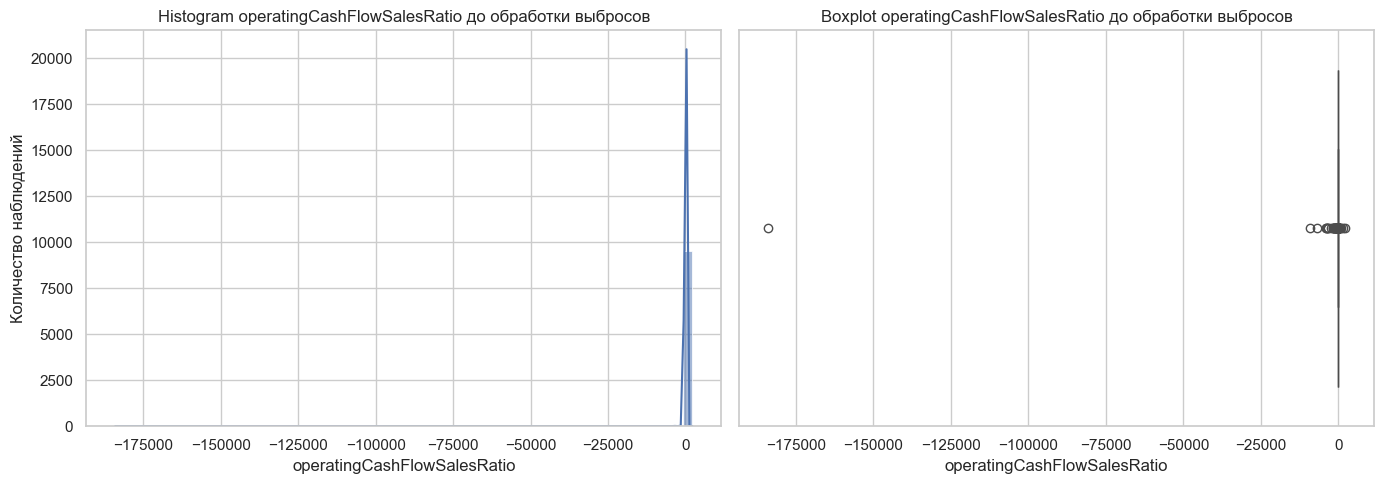

Нижний 1% квантиль: -25.430884
Верхний 99% квантиль: 2.620191
Удалили выбросов target по 1% и 99% квантилям: 192 строк
Статистика target после обработки выбросов:


,operatingCashFlowSalesRatio
count,9332.000000
mean,0.204766
std,1.441641
min,-24.893275
1%,-6.036762
5%,-0.421738
50%,0.237250
95%,1.488826
99%,2.228655
max,2.620163


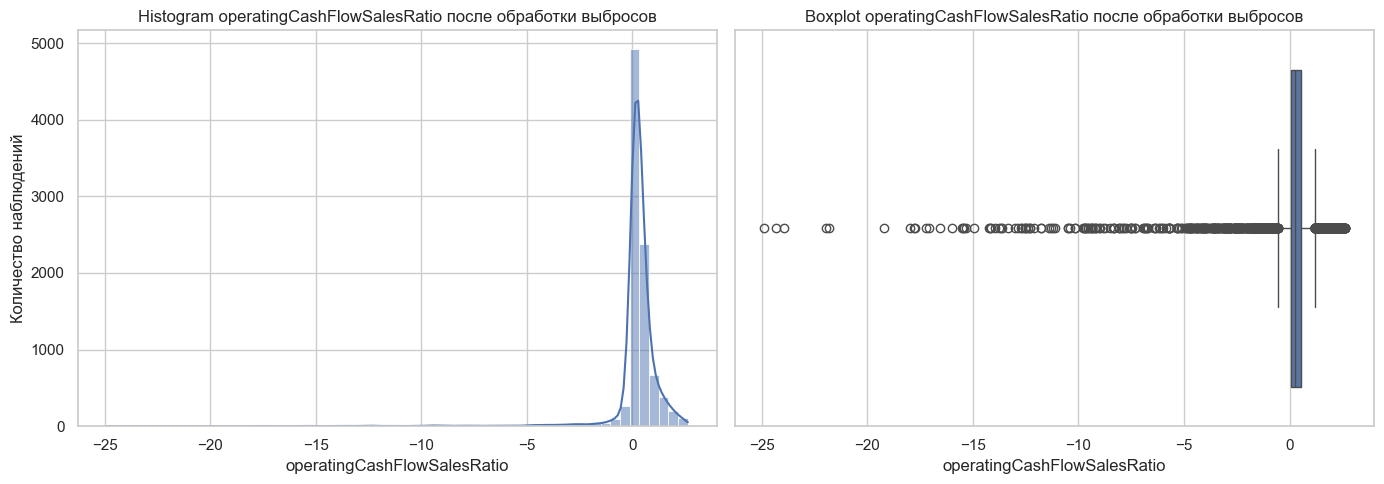

In [208]:
big_df["operatingCashFlowSalesRatio"] = (
    big_df["operating_cash_flow"] / big_df["revenue"]
)
big_df["operatingCashFlowSalesRatio"] = big_df["operatingCashFlowSalesRatio"].replace(
    [np.inf, -np.inf],
    np.nan,
)

before = len(big_df)
big_df = big_df.dropna(subset=["operatingCashFlowSalesRatio"]).copy()
print("Удалили строк с Nan или inf в target:", before - len(big_df))

print("Статистика target до обработки выбросов:")
display(big_df["operatingCashFlowSalesRatio"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(big_df["operatingCashFlowSalesRatio"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Histogram operatingCashFlowSalesRatio до обработки выбросов")
axes[0].set_xlabel("operatingCashFlowSalesRatio")
axes[0].set_ylabel("Количество наблюдений")

sns.boxplot(x=big_df["operatingCashFlowSalesRatio"], ax=axes[1])
axes[1].set_title("Boxplot operatingCashFlowSalesRatio до обработки выбросов")
axes[1].set_xlabel("operatingCashFlowSalesRatio")
plt.tight_layout()
plt.show()

lower_bound, upper_bound = big_df["operatingCashFlowSalesRatio"].quantile([0.01, 0.99])
print(f"Нижний 1% квантиль: {lower_bound:.6f}")
print(f"Верхний 99% квантиль: {upper_bound:.6f}")

before = len(big_df)
big_df = big_df.loc[
    big_df["operatingCashFlowSalesRatio"].between(lower_bound, upper_bound)
].copy()
print("Удалили выбросов target по 1% и 99% квантилям:", before - len(big_df), "строк")

print("Статистика target после обработки выбросов:")
display(big_df["operatingCashFlowSalesRatio"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(big_df["operatingCashFlowSalesRatio"], bins=60, kde=True, ax=axes[0])
axes[0].set_title("Histogram operatingCashFlowSalesRatio после обработки выбросов")
axes[0].set_xlabel("operatingCashFlowSalesRatio")
axes[0].set_ylabel("Количество наблюдений")

sns.boxplot(x=big_df["operatingCashFlowSalesRatio"], ax=axes[1])
axes[1].set_title("Boxplot operatingCashFlowSalesRatio после обработки выбросов")
axes[1].set_xlabel("operatingCashFlowSalesRatio")
plt.tight_layout()
plt.show()


Распределение целевой переменной до обработки выбросов показывает, что у показателя есть длинные хвосты и отдельные экстремальные значения. После ограничения по 1% и 99% квантилям форма распределения становится более пригодной для регрессионного эксперимента: модель меньше подстраивается под единичные аномалии и лучше описывает основную массу наблюдений.


Теперь отделим целевую переменную от основного датасета, а также уберем идентификаторы компаний и дополнительные столбцы, так как мы хотим восстанавливать целевой показатель по косвенным финансовым характеристикам. Также логарифмируем крупные финансовые величины, чтоб поможет сгладить масштаб больших занчений. 

In [209]:
from sklearn.base import clone
from sklearn.decomposition import PCA, TruncatedSVD

RANDOM_STATE = globals().get("RANDOM_STATE", 42)

target_col = "operatingCashFlowSalesRatio"
proxy_df = big_df.copy()

log_source_columns = [
    "assets",
    "liabilities",
    "equity",
    "cash",
    "net_income",
    "operating_income",
]

created_log_features = []
for col in log_source_columns:
    if col in proxy_df.columns:
        proxy_df[f"log_{col}"] = np.sign(proxy_df[col]) * np.log1p(np.abs(proxy_df[col]))
        created_log_features.append(f"log_{col}")

leakage_and_id_columns = [
    "operating_cash_flow",
    "revenue",
    target_col,
    "ticker",
    "cik",
    "company_name",
    "industry",
    "current_debt",
    "gross_profit",
    "long_term_debt",
]
lease_columns = [col for col in proxy_df.columns if "lease" in col.lower()]
columns_to_drop = leakage_and_id_columns + lease_columns

y_proxy = proxy_df[target_col].copy()
X_proxy = proxy_df.drop(columns=columns_to_drop, errors="ignore").copy()
groups_proxy = proxy_df["ticker"].fillna("unknown").astype(str)

meta_columns = [col for col in ["ticker", "sector", "year"] if col in proxy_df.columns]
proxy_meta = proxy_df[meta_columns].copy()

print("Удалены из признаков:")
print([col for col in columns_to_drop if col in proxy_df.columns])
print("Добавлены log-признаки:")
print(created_log_features)
print(f"X_proxy: {X_proxy.shape[0]} строк x {X_proxy.shape[1]} признаков")
print(f"y_proxy: {target_col}")


Удалены из признаков:
['operating_cash_flow', 'revenue', 'operatingCashFlowSalesRatio', 'ticker', 'cik', 'company_name', 'industry']
Добавлены log-признаки:
['log_assets', 'log_liabilities', 'log_equity', 'log_cash', 'log_net_income', 'log_operating_income']
X_proxy: 9332 строк x 46 признаков
y_proxy: operatingCashFlowSalesRatio


Так как нашей основной задачей является предсказание финансового показателя компаний в будущем, то подготовим тестовую выборку в таком же формате. Для каждой компании отделим последнюю запись, которую и поместим в test, а обучаться будем на оставшихся данных.

Также отдельно выделим валидационную выборку по такой же логике.


In [210]:
split_info = proxy_meta[["ticker", "year"]].copy()
split_info["year"] = pd.to_numeric(split_info["year"], errors="coerce")
split_info["row_order"] = np.arange(len(split_info))

split_info = split_info.sort_values(
    ["ticker", "year", "row_order"],
    na_position="last",
)

test_idx = split_info.groupby("ticker").tail(1).index
train_full_idx = proxy_df.index[~proxy_df.index.isin(test_idx)]

X_train_full_proxy = X_proxy.loc[train_full_idx].copy()
X_test_proxy = X_proxy.loc[test_idx].copy()
y_train_full_proxy = y_proxy.loc[train_full_idx].copy()
y_test_proxy = y_proxy.loc[test_idx].copy()
groups_train_full = groups_proxy.loc[train_full_idx].copy()
groups_test = groups_proxy.loc[test_idx].copy()
meta_train_full = proxy_meta.loc[train_full_idx].copy()
meta_test = proxy_meta.loc[test_idx].copy()

validation_info = proxy_meta.loc[train_full_idx, ["ticker", "year"]].copy()
validation_info["year"] = pd.to_numeric(validation_info["year"], errors="coerce")
validation_info["row_order"] = np.arange(len(validation_info))
validation_info = validation_info.sort_values(
    ["ticker", "year", "row_order"],
    na_position="last",
)

valid_idx = validation_info.groupby("ticker").tail(1).index
train_idx = train_full_idx[~train_full_idx.isin(valid_idx)]

X_train_proxy = X_proxy.loc[train_idx].copy()
X_valid_proxy = X_proxy.loc[valid_idx].copy()
y_train_proxy = y_proxy.loc[train_idx].copy()
y_valid_proxy = y_proxy.loc[valid_idx].copy()
groups_train = groups_proxy.loc[train_idx].copy()
groups_valid = groups_proxy.loc[valid_idx].copy()
meta_train = proxy_meta.loc[train_idx].copy()
meta_valid = proxy_meta.loc[valid_idx].copy()

print(f"Train full: {X_train_full_proxy.shape[0]} строк")
print(f"Train: {X_train_proxy.shape[0]} строк")
print(f"Validation: {X_valid_proxy.shape[0]} строк")
print(f"Test: {X_test_proxy.shape[0]} строк")
print(f"Компаний всего: {groups_proxy.nunique()}")
print(f"Компаний в test: {groups_test.nunique()}")
print(f"Компаний в validation: {groups_valid.nunique()}")

Train full: 7878 строк
Train: 6603 строк
Validation: 1275 строк
Test: 1454 строк
Компаний всего: 1454
Компаний в test: 1454
Компаний в validation: 1275


### Числовые и категориальные признаки

После разбиения фиксируются списки числовых и категориальных признаков. На этом этапе данные все еще остаются с пропусками. Заполнение пропусков, масштабирование и кодирование категорий будут выполняться внутри `Pipeline`, чтобы все параметры preprocessing обучались только на соответствующей обучающей части данных.


In [211]:
numeric_features = X_train_full_proxy.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [col for col in X_train_full_proxy.columns if col not in numeric_features]

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}")

missing_in_train = (
    X_train_proxy
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_share_train")
)
display(missing_in_train.head(15))


Числовых признаков: 45
Категориальных признаков: 1


,missing_share_train
pretax_income,0.510071
income_taxes_paid,0.467515
depreciation,0.439497
interest_paid,0.433591
dividends,0.428139
inventory,0.419203
deferred_tax_liabilities,0.411480
amortization_intangibles,0.409965
stock_repurchases,0.379222
intangible_assets_net,0.367712


### Настройка экспериментов

В эксперименте сравниваются два простых способа заполнения числовых пропусков: медиана и среднее. Это позволяет проверить, насколько чувствительны модели к выбору imputation. Для категориальных признаков используется заполнение наиболее частым значением и One-Hot Encoding.

Дополнительно проверяются PCA и TruncatedSVD. Эти методы уменьшают размерность после preprocessing и могут быть полезны, если признаки частично дублируют друг друга или содержат общие скрытые факторы. При этом модель без уменьшения размерности остается базовым вариантом для сравнения.


In [212]:
imputers = {
    "median": SimpleImputer(strategy="median", keep_empty_features=True),
    "mean": SimpleImputer(strategy="mean", keep_empty_features=True),
}

dim_reduction_methods = ["none", "PCA", "TruncatedSVD"]
n_components_grid = [5, 10, 20]

models = {
    "DummyRegressor": DummyRegressor(strategy="median"),
    "Ridge": Ridge(alpha=1.0, solver="lsqr"),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}


def make_preprocessor(numeric_imputer):
    numeric_pipeline = Pipeline([
        ("imputer", clone(numeric_imputer)),
        ("scaler", RobustScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


def make_pipeline(numeric_imputer, dim_reduction, n_components, model):
    steps = [
        ("preprocessor", make_preprocessor(numeric_imputer)),
    ]

    if dim_reduction == "PCA":
        steps.append(("dim_reduction", PCA(n_components=n_components, random_state=RANDOM_STATE)))
    elif dim_reduction == "TruncatedSVD":
        steps.append(("dim_reduction", TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)))

    steps.append(("model", clone(model)))
    return Pipeline(steps)


estimated_feature_count = len(numeric_features) + sum(
    X_train_proxy[col].nunique(dropna=True)
    for col in categorical_features
)
max_components = min(estimated_feature_count, X_train_proxy.shape[0] - 1)
valid_n_components = [n for n in n_components_grid if n <= max_components]

print(f"Оценочное число признаков после preprocessing: {estimated_feature_count}")
print(f"Для PCA/SVD будут проверены n_components: {valid_n_components}")


Оценочное число признаков после preprocessing: 56
Для PCA/SVD будут проверены n_components: [5, 10, 20]


### Эксперименты на validation

Все комбинации обучаются только на train и сравниваются на validation. Для каждой конфигурации фиксируются MSE, RMSE, MAE, R2 и MAPE. Главной метрикой выбора остается MAE, потому что она напрямую показывает средний абсолютный размер ошибки в тех же единицах, что и целевая переменная.


In [213]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }


experiment_results = []

for imputer_name, imputer in imputers.items():
    for dim_reduction in dim_reduction_methods:
        if dim_reduction == "none":
            components_to_try = [None]
        else:
            components_to_try = valid_n_components

        for n_components in components_to_try:
            for model_name, model in models.items():
                pipeline = make_pipeline(
                    numeric_imputer=imputer,
                    dim_reduction=dim_reduction,
                    n_components=n_components,
                    model=model,
                )
                pipeline.fit(X_train_proxy, y_train_proxy)
                valid_predictions = pipeline.predict(X_valid_proxy)
                metrics = calculate_metrics(y_valid_proxy, valid_predictions)

                experiment_results.append({
                    "model": model_name,
                    "imputer": imputer_name,
                    "dim_reduction": dim_reduction,
                    "n_components": n_components,
                    **metrics,
                })

                print(
                    f"{model_name} | imputer={imputer_name} | "
                    f"dim={dim_reduction} | n={n_components} | "
                    f"validation MAE={metrics['MAE']:.5f}"
                )


DummyRegressor | imputer=median | dim=none | n=None | validation MAE=0.54161
Ridge | imputer=median | dim=none | n=None | validation MAE=0.54912
RandomForestRegressor | imputer=median | dim=none | n=None | validation MAE=0.40298
GradientBoostingRegressor | imputer=median | dim=none | n=None | validation MAE=0.46403
DummyRegressor | imputer=median | dim=PCA | n=5 | validation MAE=0.54161
Ridge | imputer=median | dim=PCA | n=5 | validation MAE=0.54912
RandomForestRegressor | imputer=median | dim=PCA | n=5 | validation MAE=0.58282
GradientBoostingRegressor | imputer=median | dim=PCA | n=5 | validation MAE=0.57944
DummyRegressor | imputer=median | dim=PCA | n=10 | validation MAE=0.54161
Ridge | imputer=median | dim=PCA | n=10 | validation MAE=0.54912
RandomForestRegressor | imputer=median | dim=PCA | n=10 | validation MAE=0.57028
GradientBoostingRegressor | imputer=median | dim=PCA | n=10 | validation MAE=0.58397
DummyRegressor | imputer=median | dim=PCA | n=20 | validation MAE=0.54161
Rid

### Таблица результатов и базовая конфигурация

Таблица proxy_results_df содержит результаты базовых экспериментов на validation. На этом этапе выбирается лучшая базовая конфигурация, а затем для нее отдельно проверяются несколько вариантов гиперпараметров. Test здесь все еще не используется и остается только для финальной оценки.


,model,imputer,dim_reduction,n_components,MSE,RMSE,MAE,R2,MAPE
0,RandomForestRegressor,mean,none,NaN,2.144695,1.464478,0.402632,0.381795,223.242986
1,RandomForestRegressor,median,none,NaN,2.147499,1.465435,0.402984,0.380987,225.808844
2,GradientBoostingRegressor,median,none,NaN,2.357972,1.535569,0.464027,0.320318,265.209876
3,GradientBoostingRegressor,mean,none,NaN,2.357670,1.535471,0.464848,0.320406,264.775011
4,RandomForestRegressor,mean,TruncatedSVD,20.0,2.396103,1.547935,0.524335,0.309327,443.006431
5,RandomForestRegressor,mean,PCA,20.0,2.515402,1.586002,0.534703,0.274940,430.693307
6,DummyRegressor,median,PCA,20.0,3.524143,1.877270,0.541608,-0.015828,251.188808
7,DummyRegressor,median,PCA,10.0,3.524143,1.877270,0.541608,-0.015828,251.188808
8,DummyRegressor,median,TruncatedSVD,10.0,3.524143,1.877270,0.541608,-0.015828,251.188808
9,DummyRegressor,median,TruncatedSVD,5.0,3.524143,1.877270,0.541608,-0.015828,251.188808


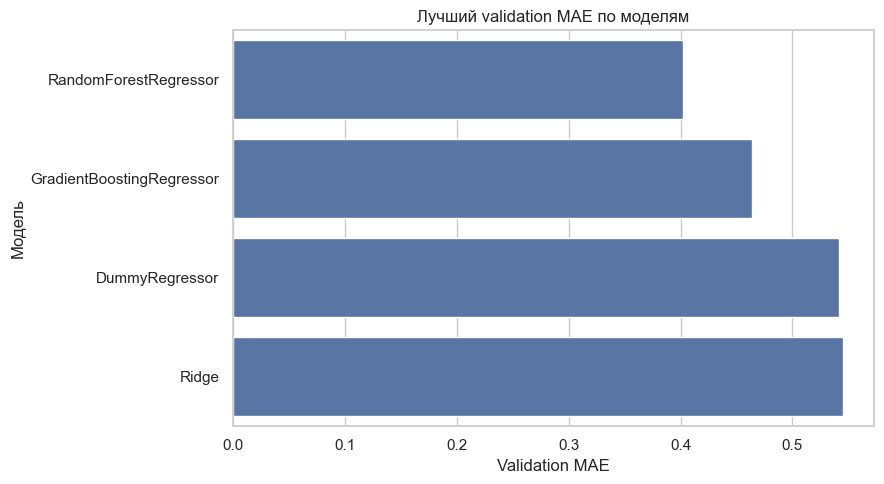

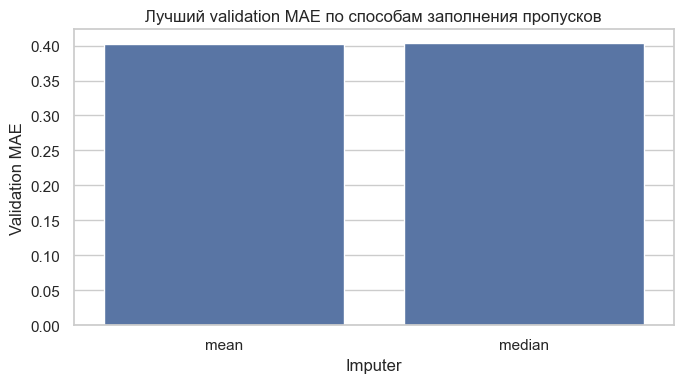

На графиках выше сравниваются лучшие результаты для каждого семейства моделей и для каждого способа заполнения пропусков. Это удобнее, чем смотреть только на полную таблицу экспериментов: сразу видно, какие решения дают наименьшую ошибку на validation.

Лучшая базовая конфигурация по validation MAE:


,model,imputer,dim_reduction,n_components,tuning,model_params
0,RandomForestRegressor,mean,none,None,base,base


In [214]:
proxy_results_df = (
    pd.DataFrame(experiment_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

proxy_results_df = proxy_results_df[
    [
        "model",
        "imputer",
        "dim_reduction",
        "n_components",
        "MSE",
        "RMSE",
        "MAE",
        "R2",
        "MAPE",
    ]
]

display(proxy_results_df)

model_mae_plot = (
    proxy_results_df
    .groupby("model", as_index=False)["MAE"]
    .min()
    .sort_values("MAE")
)

plt.figure(figsize=(9, 5))
sns.barplot(data=model_mae_plot, x="MAE", y="model")
plt.title("Лучший validation MAE по моделям")
plt.xlabel("Validation MAE")
plt.ylabel("Модель")
plt.tight_layout()
plt.show()

imputer_mae_plot = (
    proxy_results_df
    .groupby("imputer", as_index=False)["MAE"]
    .min()
    .sort_values("MAE")
)

plt.figure(figsize=(7, 4))
sns.barplot(data=imputer_mae_plot, x="imputer", y="MAE")
plt.title("Лучший validation MAE по способам заполнения пропусков")
plt.xlabel("Imputer")
plt.ylabel("Validation MAE")
plt.tight_layout()
plt.show()

display(Markdown(
    "На графиках выше сравниваются лучшие результаты для каждого семейства моделей "
    "и для каждого способа заполнения пропусков. Это удобнее, чем смотреть только "
    "на полную таблицу экспериментов: сразу видно, какие решения дают наименьшую "
    "ошибку на validation."
))

best_row = proxy_results_df.iloc[0]
best_n_components = best_row["n_components"]
if pd.isna(best_n_components):
    best_n_components = None
else:
    best_n_components = int(best_n_components)

best_config = {
    "model": best_row["model"],
    "imputer": best_row["imputer"],
    "dim_reduction": best_row["dim_reduction"],
    "n_components": best_n_components,
    "tuning": "base",
    "model_params": "base",
}
best_regression_model_name = best_config["model"]
best_validation_mae = best_row["MAE"]
best_model_for_final = models[best_config["model"]]

print("Лучшая базовая конфигурация по validation MAE:")
display(pd.DataFrame([best_config]))


### Подбор гиперпараметров

После базового сравнения моделей имеет смысл немного уточнить настройки лучшего семейства модели. Подбор выполняется только на validation: preprocessing остается внутри `Pipeline`, а test по-прежнему не используется. Здесь перебираются несколько простых значений ключевых гиперпараметров, чтобы проверить, можно ли улучшить validation MAE без усложнения всей схемы эксперимента.


RandomForestRegressor | max_depth=8, min_samples_leaf=1 | validation MAE=0.42664
RandomForestRegressor | max_depth=8, min_samples_leaf=3 | validation MAE=0.42134
RandomForestRegressor | max_depth=8, min_samples_leaf=5 | validation MAE=0.42187
RandomForestRegressor | max_depth=12, min_samples_leaf=1 | validation MAE=0.40761
RandomForestRegressor | max_depth=12, min_samples_leaf=3 | validation MAE=0.40324
RandomForestRegressor | max_depth=12, min_samples_leaf=5 | validation MAE=0.40465
RandomForestRegressor | max_depth=None, min_samples_leaf=1 | validation MAE=0.39136
RandomForestRegressor | max_depth=None, min_samples_leaf=3 | validation MAE=0.38992
RandomForestRegressor | max_depth=None, min_samples_leaf=5 | validation MAE=0.39498


,model,params,MSE,RMSE,MAE,R2,MAPE
0,RandomForestRegressor,"max_depth=None, min_samples_leaf=3",2.142366,1.463682,0.389921,0.382467,203.169026
1,RandomForestRegressor,"max_depth=None, min_samples_leaf=1",2.141330,1.463329,0.391364,0.382765,202.092523
2,RandomForestRegressor,"max_depth=None, min_samples_leaf=5",2.167946,1.472395,0.394975,0.375093,209.089876
3,RandomForestRegressor,"max_depth=12, min_samples_leaf=3",2.148395,1.465740,0.403238,0.380729,219.409957
4,RandomForestRegressor,"max_depth=12, min_samples_leaf=5",2.174756,1.474705,0.404649,0.373130,225.948218
5,RandomForestRegressor,"max_depth=12, min_samples_leaf=1",2.158103,1.469048,0.407609,0.377930,222.668118
6,RandomForestRegressor,"max_depth=8, min_samples_leaf=3",2.196232,1.481969,0.421341,0.366940,239.534667
7,RandomForestRegressor,"max_depth=8, min_samples_leaf=5",2.211309,1.487047,0.421867,0.362594,236.695694
8,RandomForestRegressor,"max_depth=8, min_samples_leaf=1",2.223470,1.491131,0.426644,0.359088,242.275783


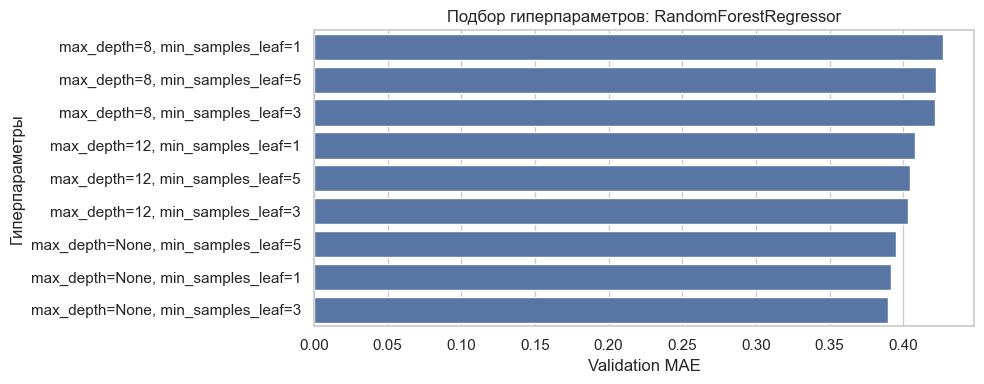

Подбор гиперпараметров улучшил validation MAE до `0.389921`. Для финального обучения будет использована настроенная версия `RandomForestRegressor`.

In [215]:
tuning_candidates = []

if best_config["model"] == "Ridge":
    for alpha in [0.1, 1.0, 10.0, 50.0]:
        tuning_candidates.append({
            "params": f"alpha={alpha}",
            "model": Ridge(alpha=alpha, solver="lsqr"),
        })

elif best_config["model"] == "RandomForestRegressor":
    for max_depth in [8, 12, None]:
        for min_samples_leaf in [1, 3, 5]:
            tuning_candidates.append({
                "params": f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}",
                "model": RandomForestRegressor(
                    n_estimators=150,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            })

elif best_config["model"] == "GradientBoostingRegressor":
    for n_estimators in [100, 150]:
        for learning_rate in [0.03, 0.05, 0.1]:
            for max_depth in [2, 3]:
                tuning_candidates.append({
                    "params": (
                        f"n_estimators={n_estimators}, "
                        f"learning_rate={learning_rate}, max_depth={max_depth}"
                    ),
                    "model": GradientBoostingRegressor(
                        n_estimators=n_estimators,
                        learning_rate=learning_rate,
                        max_depth=max_depth,
                        random_state=RANDOM_STATE,
                    ),
                })

else:
    tuning_candidates.append({
        "params": "DummyRegressor без дополнительных гиперпараметров",
        "model": models["DummyRegressor"],
    })

tuning_results = []

for candidate_id, candidate in enumerate(tuning_candidates):
    pipeline = make_pipeline(
        numeric_imputer=imputers[best_config["imputer"]],
        dim_reduction=best_config["dim_reduction"],
        n_components=best_config["n_components"],
        model=candidate["model"],
    )
    pipeline.fit(X_train_proxy, y_train_proxy)
    valid_predictions = pipeline.predict(X_valid_proxy)
    metrics = calculate_metrics(y_valid_proxy, valid_predictions)

    tuning_results.append({
        "candidate_id": candidate_id,
        "model": best_config["model"],
        "params": candidate["params"],
        **metrics,
    })

    print(
        f"{best_config['model']} | {candidate['params']} | "
        f"validation MAE={metrics['MAE']:.5f}"
    )

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)
display(tuning_results_df.drop(columns=["candidate_id"]))

plt.figure(figsize=(10, max(4, 0.35 * len(tuning_results_df))))
sns.barplot(
    data=tuning_results_df.sort_values("MAE", ascending=False),
    x="MAE",
    y="params",
)
plt.title(f"Подбор гиперпараметров: {best_config['model']}")
plt.xlabel("Validation MAE")
plt.ylabel("Гиперпараметры")
plt.tight_layout()
plt.show()

best_tuning_row = tuning_results_df.iloc[0]

if best_tuning_row["MAE"] < best_validation_mae:
    best_validation_mae = best_tuning_row["MAE"]
    best_config["tuning"] = "tuned"
    best_config["model_params"] = best_tuning_row["params"]
    best_model_for_final = tuning_candidates[int(best_tuning_row["candidate_id"])]["model"]
    display(Markdown(
        f"Подбор гиперпараметров улучшил validation MAE до "
        f"`{best_validation_mae:.6f}`. Для финального обучения будет "
        f"использована настроенная версия `{best_config['model']}`."
    ))
else:
    display(Markdown(
        f"Подбор гиперпараметров не улучшил базовый validation MAE "
        f"`{best_validation_mae:.6f}`. Для финального обучения остается "
        f"исходная конфигурация."
    ))


### Финальное обучение после подбора

После выбора базовой конфигурации и проверки гиперпараметров модель заново обучается на всем `train_full`. Только здесь используется test: он остается независимой выборкой для финальной оценки качества.


In [216]:
best_regression_model_name = best_config["model"]

best_pipeline = make_pipeline(
    numeric_imputer=imputers[best_config["imputer"]],
    dim_reduction=best_config["dim_reduction"],
    n_components=best_config["n_components"],
    model=best_model_for_final,
)
best_pipeline.fit(X_train_full_proxy, y_train_full_proxy)
best_predictions = best_pipeline.predict(X_test_proxy)
test_metrics = calculate_metrics(y_test_proxy, best_predictions)

dummy_pipeline = make_pipeline(
    numeric_imputer=imputers["median"],
    dim_reduction="none",
    n_components=None,
    model=models["DummyRegressor"],
)
dummy_pipeline.fit(X_train_full_proxy, y_train_full_proxy)
dummy_test_predictions = dummy_pipeline.predict(X_test_proxy)
dummy_test_metrics = calculate_metrics(y_test_proxy, dummy_test_predictions)

print("Финальная конфигурация после подбора:")
display(pd.DataFrame([best_config]))

print("Финальные метрики лучшей модели на test:")
display(pd.DataFrame([test_metrics]))

print("Финальные метрики DummyRegressor на test:")
display(pd.DataFrame([dummy_test_metrics]))


Финальная конфигурация после подбора:


,model,imputer,dim_reduction,n_components,tuning,model_params
0,RandomForestRegressor,mean,none,None,tuned,"max_depth=None, min_samples_leaf=3"


Финальные метрики лучшей модели на test:


,MSE,RMSE,MAE,R2,MAPE
0,1.313102,1.145906,0.387649,0.57692,271.218023


Финальные метрики DummyRegressor на test:


,MSE,RMSE,MAE,R2,MAPE
0,3.163106,1.778512,0.548244,-0.01915,297.822192


### Сравнение методов уменьшения размерности

После основного цикла отдельно сравниваются варианты без изменения размерности, PCA и TruncatedSVD. Здесь важно понять не только то, какая конкретная модель стала лучшей, но и помогло ли само уменьшение размерности. Если лучший результат остается у варианта без примененных изменений, значит исходное пространство признаков оказалось достаточно информативным для моделей.


,mean_MAE,best_MAE,experiments
dim_reduction,,,
none,0.499398,0.402632,8
TruncatedSVD,0.563968,0.524335,24
PCA,0.565022,0.534703,24


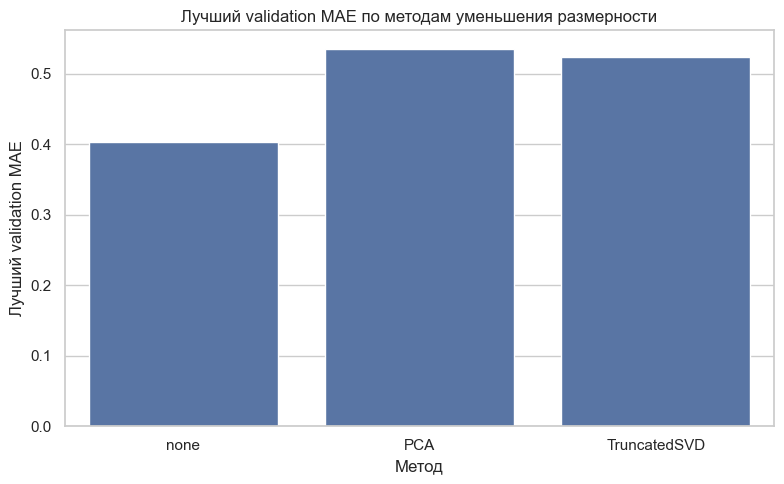

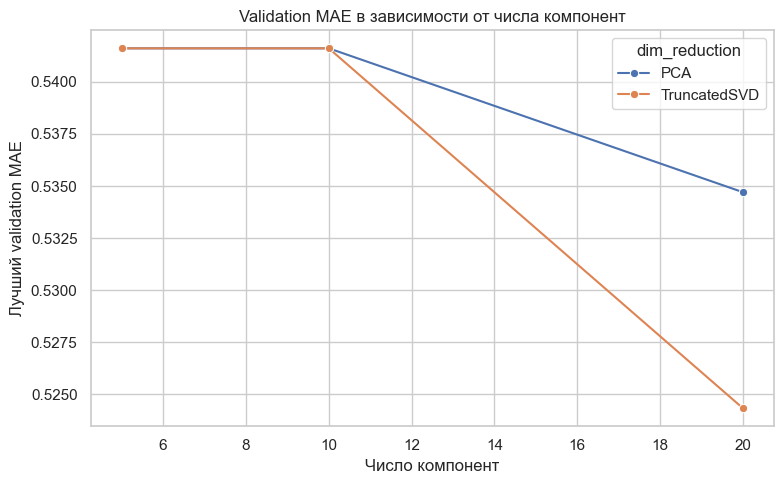

**Вывод:** На validation уменьшение размерности не улучшило лучший MAE: без PCA/SVD 0.402632, с PCA/SVD 0.524335.

In [217]:
dim_reduction_summary = (
    proxy_results_df
    .groupby("dim_reduction")
    .agg(
        mean_MAE=("MAE", "mean"),
        best_MAE=("MAE", "min"),
        experiments=("MAE", "count"),
    )
    .sort_values("best_MAE")
)

display(dim_reduction_summary)

dim_order = [
    method
    for method in ["none", "PCA", "TruncatedSVD"]
    if method in dim_reduction_summary.index
]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=dim_reduction_summary.reset_index(),
    x="dim_reduction",
    y="best_MAE",
    order=dim_order,
)
plt.title("Лучший validation MAE по методам уменьшения размерности")
plt.xlabel("Метод")
plt.ylabel("Лучший validation MAE")
plt.tight_layout()
plt.show()

components_plot = (
    proxy_results_df
    .loc[proxy_results_df["dim_reduction"].isin(["PCA", "TruncatedSVD"])]
    .dropna(subset=["n_components"])
    .copy()
)

if not components_plot.empty:
    components_plot["n_components"] = components_plot["n_components"].astype(int)
    components_plot = (
        components_plot
        .groupby(["dim_reduction", "n_components"], as_index=False)["MAE"]
        .min()
    )

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=components_plot,
        x="n_components",
        y="MAE",
        hue="dim_reduction",
        marker="o",
    )
    plt.title("Validation MAE в зависимости от числа компонент")
    plt.xlabel("Число компонент")
    plt.ylabel("Лучший validation MAE")
    plt.tight_layout()
    plt.show()

best_without_reduction = proxy_results_df.loc[
    proxy_results_df["dim_reduction"] == "none",
    "MAE",
].min()
best_with_reduction = proxy_results_df.loc[
    proxy_results_df["dim_reduction"] != "none",
    "MAE",
].min()

if best_with_reduction < best_without_reduction:
    reduction_text = (
        f"На validation уменьшение размерности помогло: лучший MAE с PCA/SVD "
        f"{best_with_reduction:.6f} против {best_without_reduction:.6f} без него."
    )
else:
    reduction_text = (
        f"На validation уменьшение размерности не улучшило лучший MAE: без PCA/SVD "
        f"{best_without_reduction:.6f}, с PCA/SVD {best_with_reduction:.6f}."
    )

display(Markdown(f"**Вывод:** {reduction_text}"))


### Анализ лучшей модели на test

Для выбранной модели построим график, показывающий насколько предсказания близки к фактическим значениям. Распределение ошибок помогает увидеть, есть ли заметное смещение или большое число сильных промахов. Дополнительно считается MAE по секторам и годам, чтобы понять, в каких частях данных модель ошибается сильнее.


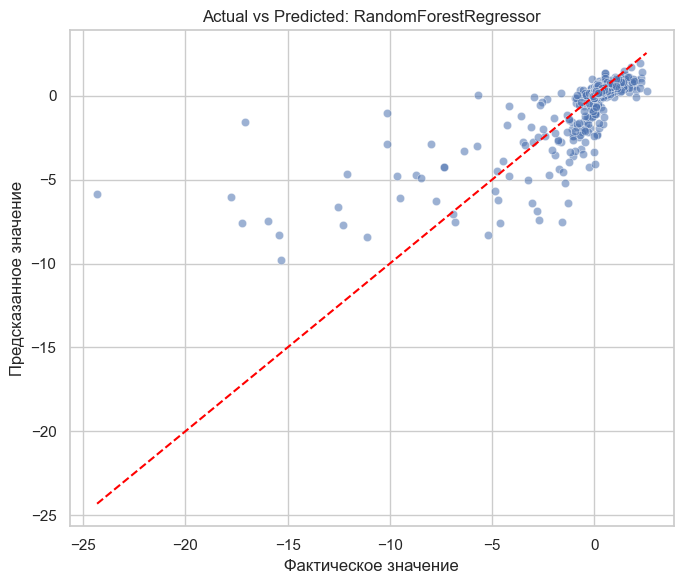

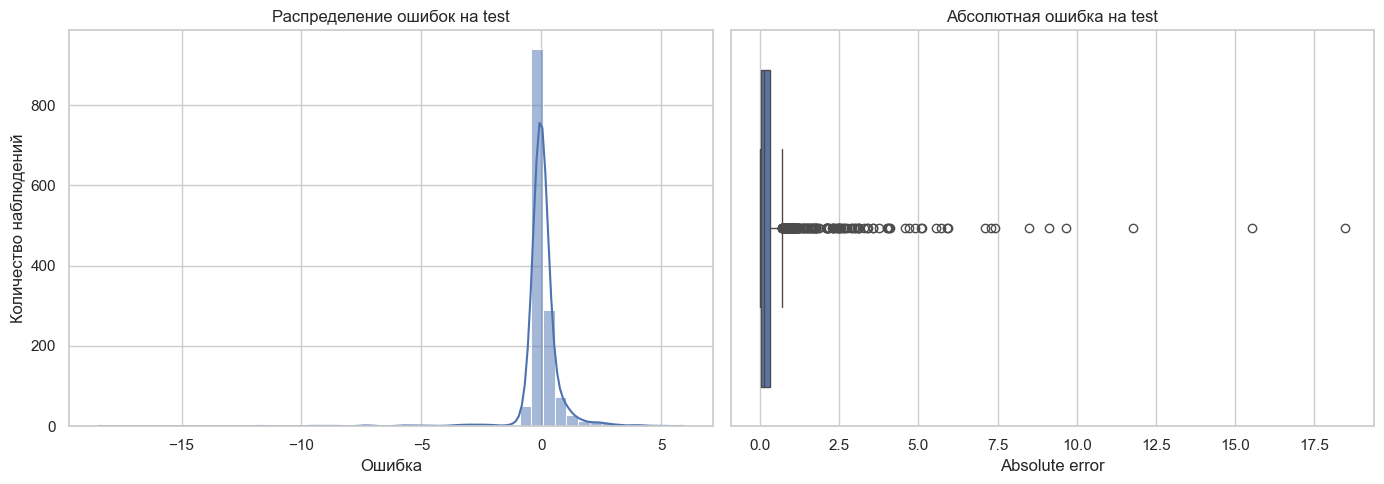

График `Actual vs Predicted` показывает, насколько предсказания держатся около диагонали идеального прогноза. Распределение ошибок дополняет эту картину: по нему видно, есть ли систематическое смещение и насколько часто возникают крупные промахи.

MAE по секторам:


,MAE
sector,
Health Care,1.047241
Communication,0.416466
Materials,0.402535
Information Technology,0.385424
Energy,0.301272
Real Estate,0.196495
Consumer Discretionary,0.195228
Communication Services,0.183961
Industrials,0.182009


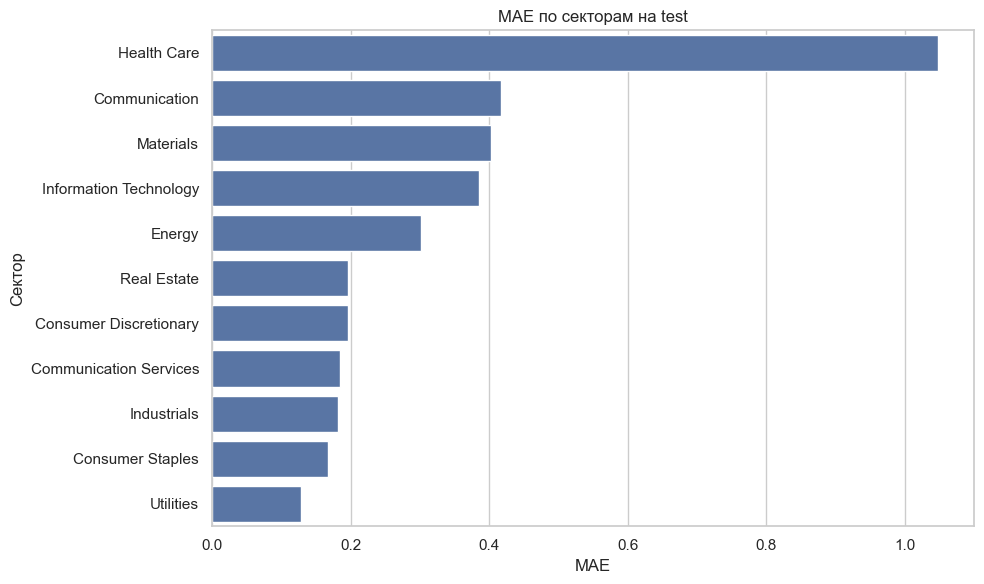

MAE по годам:


,MAE
year,
2010,0.290058
2011,0.451658
2012,0.321558
2013,0.693326
2014,0.673640
2015,0.384222
2016,0.218462
2017,0.293166
2018,0.490791


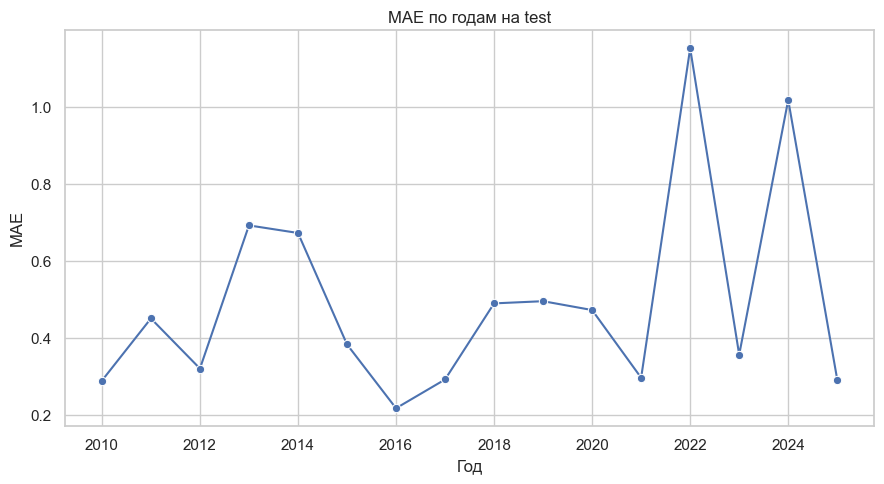

Разбиение ошибки по секторам и годам помогает увидеть, где модель работает стабильнее, а где качество хуже. Такие различия могут быть связаны с особенностями отраслей, разным числом наблюдений или изменениями финансовой среды в отдельные годы.

,feature,importance
12,current_liabilities,0.076666
1,year,0.066171
20,retained_earnings,0.038902
0,sector,0.034691
14,accounts_receivable,0.030906
22,comprehensive_income,0.028249
15,accounts_payable,0.025917
23,ppe_net,0.017773
35,other_noncurrent_assets,0.015383
17,investing_cash_flow,0.013845


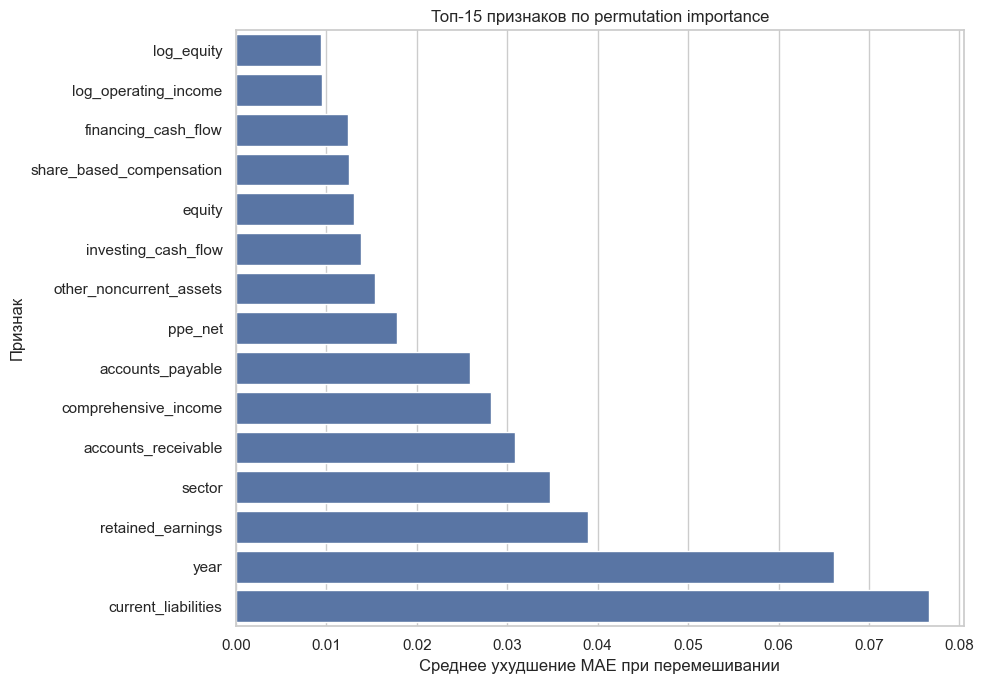

Permutation importance оценивает, насколько ухудшается качество модели, если перемешать один исходный признак. Этот график не доказывает причинную связь, но помогает понять, какие переменные сильнее всего влияют на предсказания выбранного pipeline.

In [218]:
error_df = meta_test.reset_index(drop=True).copy()
error_df["actual"] = np.asarray(y_test_proxy)
error_df["predicted"] = np.asarray(best_predictions)
error_df["error"] = error_df["actual"] - error_df["predicted"]
error_df["abs_error"] = error_df["error"].abs()

min_value = min(error_df["actual"].min(), error_df["predicted"].min())
max_value = max(error_df["actual"].max(), error_df["predicted"].max())

plt.figure(figsize=(7, 6))
sns.scatterplot(data=error_df, x="actual", y="predicted", alpha=0.55)
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")
plt.title(f"Actual vs Predicted: {best_regression_model_name}")
plt.xlabel("Фактическое значение")
plt.ylabel("Предсказанное значение")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(error_df["error"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Распределение ошибок на test")
axes[0].set_xlabel("Ошибка")
axes[0].set_ylabel("Количество наблюдений")

sns.boxplot(x=error_df["abs_error"], ax=axes[1])
axes[1].set_title("Абсолютная ошибка на test")
axes[1].set_xlabel("Absolute error")

plt.tight_layout()
plt.show()

display(Markdown(
    "График `Actual vs Predicted` показывает, насколько предсказания держатся "
    "около диагонали идеального прогноза. Распределение ошибок дополняет эту "
    "картину: по нему видно, есть ли систематическое смещение и насколько часто "
    "возникают крупные промахи."
))

sector_mae = (
    error_df
    .groupby("sector")["abs_error"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("MAE")
)
print("MAE по секторам:")
display(sector_mae)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=sector_mae.reset_index(),
    x="MAE",
    y="sector",
)
plt.title("MAE по секторам на test")
plt.xlabel("MAE")
plt.ylabel("Сектор")
plt.tight_layout()
plt.show()

year_mae = (
    error_df
    .groupby("year")["abs_error"]
    .mean()
    .sort_index()
    .to_frame("MAE")
)
print("MAE по годам:")
display(year_mae)

plt.figure(figsize=(9, 5))
sns.lineplot(data=year_mae.reset_index(), x="year", y="MAE", marker="o")
plt.title("MAE по годам на test")
plt.xlabel("Год")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

display(Markdown(
    "Разбиение ошибки по секторам и годам помогает увидеть, где модель работает "
    "стабильнее, а где качество хуже. Такие различия могут быть связаны с "
    "особенностями отраслей, разным числом наблюдений или изменениями финансовой "
    "среды в отдельные годы."
))

permutation = permutation_importance(
    best_pipeline,
    X_test_proxy,
    y_test_proxy,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": X_test_proxy.columns,
        "importance": permutation.importances_mean,
    })
    .sort_values("importance", ascending=False)
)

top_importance = importance_df.head(15)
display(top_importance)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_importance.sort_values("importance"),
    x="importance",
    y="feature",
)
plt.title("Топ-15 признаков по permutation importance")
plt.xlabel("Среднее ухудшение MAE при перемешивании")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

display(Markdown(
    "Permutation importance оценивает, насколько ухудшается качество модели, "
    "если перемешать один исходный признак. Этот график не доказывает причинную "
    "связь, но помогает понять, какие переменные сильнее всего влияют на "
    "предсказания выбранного pipeline."
))


### Итоговый вывод

По validation лучшей оказалась конфигурация RandomForestRegressor с заполнением пропусков mean и вариантом уменьшения размерности none. После выбора модель была заново обучена на всем обучающей выборке и на тестовой выборка были получены следующие результаты:
* MSE 1.313102
* RMSE 1.145906
* MAE 0.387649
* R2 0.5769
* MAPE 271.22%. 

На тестовой выборке она лучше DummyRegressor на 0.160594 MAE (29.29%).

Сравнение вариантов с PCA и TruncatedSVD не показало улучшений результатов, а наоборот значительно их понизило. Среди способов заполнения пропусков лучше всего на validation сработал mean с MAE 0.402632.
